# March Madness 2026: Data-Driven Final Four Analysis

A composite analytical pipeline using KenPom efficiency metrics, real NCAA NET rankings,
committee metrics (SOR, WAB, KPI, BPI), quad records, Monte Carlo bracket simulation, and seed-constraint optimization.

**Seed constraint:** Sum of seeds >= 15 | **Method:** Composite model -> 10K Monte Carlo sims -> Brute-force optimization

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import seaborn as sns
import re, os, warnings
from itertools import product as iterproduct
from collections import defaultdict

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = [12, 8]

REGION_COLORS = {'East': '#1f77b4', 'South': '#d62728', 'West': '#2ca02c', 'Midwest': '#ff7f0e'}
SCRAPED_DIR = 'scraped_data'
os.makedirs(SCRAPED_DIR, exist_ok=True)
print('Setup complete.')

Setup complete.


## 2. Load KenPom Data

Parse team efficiency ratings, offensive/defensive metrics, and strength of schedule.

In [2]:
col_names = ['Rk', 'Team', 'Conf', 'W_L', 'NetRtg', 'ORtg', 'DRtg', 'AdjT', 'Luck',
             'SOS_NetRtg', 'SOS_ORtg', 'SOS_DRtg', 'NCSOS_NetRtg']
kenpom = pd.read_csv('scraped_data/kenpom.csv', skiprows=2, header=None, names=col_names)

# Parse seed from team name (e.g., "Duke 1" -> ("Duke", 1))
def parse_team_seed(team_str):
    m = re.match(r'(.+?)\s+(\d+)$', str(team_str))
    if m:
        return m.group(1).strip(), int(m.group(2))
    return str(team_str).strip(), None

kenpom[['TeamName', 'KP_Seed']] = kenpom['Team'].apply(
    lambda x: pd.Series(parse_team_seed(x))
)

for col in ['Rk', 'NetRtg', 'ORtg', 'DRtg', 'AdjT', 'Luck',
            'SOS_NetRtg', 'SOS_ORtg', 'SOS_DRtg', 'NCSOS_NetRtg']:
    kenpom[col] = pd.to_numeric(kenpom[col], errors='coerce')
kenpom['Rk'] = kenpom['Rk'].astype(int)
kenpom['KP_Seed'] = kenpom['KP_Seed'].astype(int)

print(f'Loaded {len(kenpom)} teams from KenPom')
kenpom[['Rk', 'TeamName', 'KP_Seed', 'Conf', 'W_L', 'NetRtg', 'ORtg', 'DRtg', 'SOS_NetRtg']].head(10)

Loaded 68 teams from KenPom


,Rk,TeamName,KP_Seed,Conf,W_L,NetRtg,ORtg,DRtg,SOS_NetRtg
0,1,Duke,1,ACC,32-2,38.90,127.9,89.1,14.29
1,2,Arizona,1,B12,32-2,37.62,127.7,90.0,14.94
2,3,Michigan,1,B10,31-3,37.58,126.6,89.0,16.65
3,4,Florida,1,SEC,26-7,33.78,125.5,91.8,16.01
4,5,Houston,2,B12,28-6,33.39,124.8,91.5,13.56
5,6,Iowa St.,2,B12,27-7,32.38,123.8,91.4,12.40
6,7,Illinois,3,B10,24-8,32.09,131.2,99.1,13.64
7,8,Purdue,2,B10,27-8,31.19,131.6,100.4,15.88
8,9,Michigan St.,3,B10,25-7,28.30,123.0,94.7,13.69
9,10,Gonzaga,3,WCC,30-3,28.10,122.0,93.9,5.90


## 3. Load Bracket Data & Merge

Resolve play-in games, normalize team names across sources, and merge bracket structure with KenPom data.

In [3]:
bracket = pd.read_csv('scraped_data/bracket.csv')

# KenPom name -> standard/bracket name
# Canonical name mapping: variant -> standard bracket name (shared across all data sources)
NAME_ALIASES = {
    'Michigan St.': 'Michigan State', 'Iowa St.': 'Iowa State',
    'Ohio St.': 'Ohio State', 'Connecticut': 'UConn',
    'Utah St.': 'Utah State', 'Miami FL': 'Miami (FL)',
    'N.C. State': 'NC State', 'North Dakota St.': 'North Dakota State',
    'Wright St.': 'Wright State', 'Kennesaw St.': 'Kennesaw State',
    'Miami OH': 'Miami (OH)', 'Tennessee St.': 'Tennessee State',
    'LIU': 'Long Island University', 'Queens': 'Queens (NC)',
    'South Fla.': 'South Florida', 'UNI': 'Northern Iowa',
    'California Baptist': 'Cal Baptist',
    "Saint Mary's (CA)": "Saint Mary's", "St. John's (NY)": "St. John's",
    'Long Island': 'Long Island University',
    "Saint Mary's College": "Saint Mary's", "Saint John's": "St. John's",
    'North Carolina State': 'NC State',
}
kenpom['StdName'] = kenpom['TeamName'].replace(NAME_ALIASES)

# Play-in resolutions (winner projected by KenPom rank)
PLAYIN = {
    'NC State/Texas': ('NC State', 11),       # KP #34 > #37
    'SMU/Miami (OH)': ('SMU', 11),            # KP #42 > #93
    'Howard/UMBC': ('UMBC', 16),              # KP #188 > #204
    'Lehigh/Prairie View A&M': ('Lehigh', 16) # KP #284 > #288
}

rows = []
for _, row in bracket.iterrows():
    r = row.to_dict()
    for tcol, scol in [('TeamA', 'SeedA'), ('TeamB', 'SeedB')]:
        if r[tcol] in PLAYIN:
            r[tcol], r[scol] = PLAYIN[r[tcol]]
    rows.append(r)
bracket = pd.DataFrame(rows)

print('Play-in projections:')
for matchup, (winner, seed) in PLAYIN.items():
    print(f'  {matchup} -> {winner} (seed {seed})')

# Build flat team list from bracket
team_rows = []
for _, row in bracket.iterrows():
    team_rows.append({'StdName': row['TeamA'], 'Region': row['Region'],
                      'Seed': int(row['SeedA']), 'GameID': row['GameID']})
    team_rows.append({'StdName': row['TeamB'], 'Region': row['Region'],
                      'Seed': int(row['SeedB']), 'GameID': row['GameID']})
bracket_teams = pd.DataFrame(team_rows).drop_duplicates(subset='StdName')

# Merge with KenPom
df = bracket_teams.merge(
    kenpom.drop(columns=['Team', 'TeamName', 'KP_Seed']),
    on='StdName', how='left'
)

missing = df[df['NetRtg'].isna()]['StdName'].tolist()
if missing:
    print(f'\nWARNING: No KenPom data for: {missing}')
else:
    print(f'\nAll {len(df)} tournament teams matched successfully.')

df.sort_values('Rk')[['StdName', 'Region', 'Seed', 'Rk', 'NetRtg', 'ORtg', 'DRtg', 'SOS_NetRtg']].head(16)

Play-in projections:
  NC State/Texas -> NC State (seed 11)
  SMU/Miami (OH) -> SMU (seed 11)
  Howard/UMBC -> UMBC (seed 16)
  Lehigh/Prairie View A&M -> Lehigh (seed 16)

All 64 tournament teams matched successfully.


,StdName,Region,Seed,Rk,NetRtg,ORtg,DRtg,SOS_NetRtg
0,Duke,East,1,1,38.90,127.9,89.1,14.29
32,Arizona,West,1,2,37.62,127.7,90.0,14.94
48,Michigan,Midwest,1,3,37.58,126.6,89.0,16.65
16,Florida,South,1,4,33.78,125.5,91.8,16.01
30,Houston,South,2,5,33.39,124.8,91.5,13.56
62,Iowa State,Midwest,2,6,32.38,123.8,91.4,12.40
26,Illinois,South,3,7,32.09,131.2,99.1,13.64
46,Purdue,West,2,8,31.19,131.6,100.4,15.88
10,Michigan State,East,3,9,28.30,123.0,94.7,13.69
42,Gonzaga,West,3,10,28.10,122.0,93.9,5.90


## 4. Load NET Rankings & Tournament Team Metrics

Load real NCAA NET rankings and rich team-sheet metrics (KPI, SOR, WAB, BPI) from CSV files.
This replaces web scraping with reliable local data and adds truly independent metrics beyond KenPom.

In [4]:
# --- Load NET Rankings from CSV (all 365 D1 teams) ---
NET_CSV = 'scraped_data/ncaa-net-rankings.csv'
TEAM_SHEET_CSV = os.path.join(SCRAPED_DIR, 'tournament_teams.csv')

has_net = False
has_teamsheet = False


if os.path.exists(NET_CSV):
    net_df = pd.read_csv(NET_CSV)
    net_df['School'] = net_df['School'].str.strip()
    net_df['StdName'] = net_df['School'].replace(NAME_ALIASES)
    has_net = True
    print(f'Loaded NET rankings: {len(net_df)} teams from {NET_CSV}')

    # Parse quad records from NET CSV (format: "17-2") using vectorized str.extract
    def parse_wl(series):
        parsed = series.str.extract(r'(\d+)-(\d+)')
        w = pd.to_numeric(parsed[0], errors='coerce').fillna(0).astype(int)
        l = pd.to_numeric(parsed[1], errors='coerce').fillna(0).astype(int)
        return w, l
    net_df['Q1_W'], net_df['Q1_L'] = parse_wl(net_df['Quad 1'])
    net_df['Q2_W'], net_df['Q2_L'] = parse_wl(net_df['Quad 2'])
    net_df['Q1_WinPct'] = net_df['Q1_W'] / (net_df['Q1_W'] + net_df['Q1_L']).replace(0, np.nan)
    net_df['Q1_WinPct'] = net_df['Q1_WinPct'].fillna(0)
    q1q2_total = net_df['Q1_W'] + net_df['Q2_W'] + net_df['Q1_L'] + net_df['Q2_L']
    net_df['Q1Q2_WinPct'] = (net_df['Q1_W'] + net_df['Q2_W']) / q1q2_total.replace(0, np.nan)
    net_df['Q1Q2_WinPct'] = net_df['Q1Q2_WinPct'].fillna(0)
else:
    print(f'WARNING: {NET_CSV} not found - using KenPom rank as NET proxy')

# --- Load tournament team sheet metrics (KPI, SOR, WAB, BPI, etc.) ---
if os.path.exists(TEAM_SHEET_CSV):
    ts_df = pd.read_csv(TEAM_SHEET_CSV)
    ts_df['StdName'] = ts_df['team'].replace(NAME_ALIASES)
    has_teamsheet = True
    print(f'Loaded tournament team sheets: {len(ts_df)} teams from {TEAM_SHEET_CSV}')
else:
    print(f'WARNING: {TEAM_SHEET_CSV} not found - SOR/WAB/KPI metrics unavailable')

# --- Merge NET rankings ---
if has_net:
    net_merge = net_df[['StdName', 'Rank', 'Q1_W', 'Q1_L', 'Q1_WinPct', 'Q2_W', 'Q2_L', 'Q1Q2_WinPct']].copy()
    net_merge = net_merge.rename(columns={'Rank': 'NET_Rank'})
    df = df.merge(net_merge, on='StdName', how='left')
    matched = df['NET_Rank'].notna().sum()
    print(f'Matched {matched}/{len(df)} teams with NET rankings')
    df['NET_Rank'] = df['NET_Rank'].fillna(df['Rk'])
    df['Q1_WinPct'] = df['Q1_WinPct'].fillna(0)
    df['Q1Q2_WinPct'] = df['Q1Q2_WinPct'].fillna(0)
else:
    df['NET_Rank'] = df['Rk'].astype(float)
    df['Q1_WinPct'] = 0.0
    df['Q1Q2_WinPct'] = 0.0
    df['Q1_W'] = np.nan
    df['Q1_L'] = np.nan

# --- Merge team sheet metrics (SOR, WAB, KPI, BPI, NET SOS) ---
if has_teamsheet:
    ts_cols = ts_df[['StdName', 'net_sos', 'kpi', 'sor', 'wab', 'bpi', 'avg_net_wins', 'avg_net_losses']].copy()
    ts_cols = ts_cols.rename(columns={
        'net_sos': 'NET_SOS', 'kpi': 'KPI', 'sor': 'SOR',
        'wab': 'WAB', 'bpi': 'BPI',
        'avg_net_wins': 'Avg_NET_Wins', 'avg_net_losses': 'Avg_NET_Losses',
    })
    for col in ['NET_SOS', 'KPI', 'SOR', 'WAB', 'BPI', 'Avg_NET_Wins', 'Avg_NET_Losses']:
        ts_cols[col] = pd.to_numeric(ts_cols[col], errors='coerce')
    df = df.merge(ts_cols, on='StdName', how='left')
    ts_matched = df['SOR'].notna().sum()
    print(f'Matched {ts_matched}/{len(df)} teams with team sheet metrics (SOR/WAB/KPI/BPI)')
    if ts_matched < len(df):
        missing_ts = df[df['SOR'].isna()]['StdName'].tolist()
        print(f'  Missing: {missing_ts}')
else:
    for col in ['NET_SOS', 'KPI', 'SOR', 'WAB', 'BPI', 'Avg_NET_Wins', 'Avg_NET_Losses']:
        df[col] = np.nan

has_quad = has_net and df['Q1_WinPct'].sum() > 0

# Show NET vs KenPom rank comparison
print(f'\nNET vs KenPom rank divergence (top 10 by |diff|):')
_diff = (df['NET_Rank'] - df['Rk']).abs()
for idx in _diff.nlargest(10).index:
    row = df.loc[idx]
    print(f'  {row["StdName"]}: NET #{int(row["NET_Rank"])} vs KP #{int(row["Rk"])} (diff: {int(row["NET_Rank"] - row["Rk"])})')

print(f'\nData ready: {len(df)} teams')
print(f'  NET rankings: {"real" if has_net else "KenPom proxy"}')
print(f'  Quad records: {"yes" if has_quad else "no"}')
print(f'  Team sheet metrics (SOR/WAB/KPI/BPI): {"yes" if has_teamsheet else "no"}')

Loaded NET rankings: 365 teams from scraped_data/ncaa-net-rankings.csv
Loaded tournament team sheets: 68 teams from scraped_data/tournament_teams.csv
Matched 64/64 teams with NET rankings
Matched 64/64 teams with team sheet metrics (SOR/WAB/KPI/BPI)

NET vs KenPom rank divergence (top 10 by |diff|):
  Troy: NET #125 vs KP #143 (diff: -18)
  Long Island University: NET #198 vs KP #216 (diff: -18)
  High Point: NET #75 vs KP #92 (diff: -17)
  Tennessee State: NET #172 vs KP #186 (diff: -14)
  Wright State: NET #127 vs KP #140 (diff: -13)
  Penn: NET #139 vs KP #151 (diff: -12)
  McNeese: NET #56 vs KP #67 (diff: -11)
  Siena: NET #183 vs KP #193 (diff: -10)
  Saint Louis: NET #31 vs KP #41 (diff: -10)
  Akron: NET #54 vs KP #64 (diff: -10)

Data ready: 64 teams
  NET rankings: real
  Quad records: yes
  Team sheet metrics (SOR/WAB/KPI/BPI): yes


In [5]:
# --- Load Injury Adjustments (optional: enhances model with real-time injury data) ---
INJURY_ADJ_CSV = os.path.join(SCRAPED_DIR, 'injury_adjustments.csv')
has_injuries = False

if os.path.exists(INJURY_ADJ_CSV):
    inj_df = pd.read_csv(INJURY_ADJ_CSV)
    inj_df = inj_df.rename(columns={'team': 'StdName'})
    # Merge injury data
    df = df.merge(
        inj_df[['StdName', 'num_injuries', 'total_penalty', 'adjusted_NetRtg',
                'injury_health_raw', 'key_injuries_summary']],
        on='StdName', how='left'
    )
    df['total_penalty'] = df['total_penalty'].fillna(0)
    df['adjusted_NetRtg'] = df['adjusted_NetRtg'].fillna(df['NetRtg'])
    df['injury_health_raw'] = df['injury_health_raw'].fillna(0)
    df['num_injuries'] = df['num_injuries'].fillna(0).astype(int)
    df['key_injuries_summary'] = df['key_injuries_summary'].fillna('')
    has_injuries = True

    injured = df[df['total_penalty'] != 0].sort_values('total_penalty')
    print(f'Loaded injury adjustments: {len(inj_df)} teams from {INJURY_ADJ_CSV}')
    print(f'Teams with injury penalties: {len(injured)}')
    if len(injured) > 0:
        for _, row in injured.iterrows():
            print(f'  {row["StdName"]}: penalty={row["total_penalty"]:+.3f}, '
                  f'adjusted NetRtg={row["adjusted_NetRtg"]:.2f} (was {row["NetRtg"]:.2f})')
else:
    df['total_penalty'] = 0.0
    df['adjusted_NetRtg'] = df['NetRtg']
    df['injury_health_raw'] = 0.0
    df['num_injuries'] = 0
    df['key_injuries_summary'] = ''
    print(f'WARNING: {INJURY_ADJ_CSV} not found - no injury adjustments applied')
    print('  Run: python scripts/scrape_injuries.py && python scripts/scrape_player_stats.py')

print(f'\nInjury data: {"available" if has_injuries else "not available (using unadjusted ratings)"}')

Loaded injury adjustments: 68 teams from scraped_data/injury_adjustments.csv
Teams with injury penalties: 38
  Texas Tech: penalty=-2.024, adjusted NetRtg=23.18 (was 25.20)
  Penn: penalty=-1.887, adjusted NetRtg=-0.56 (was 1.33)
  BYU: penalty=-1.796, adjusted NetRtg=21.41 (was 23.21)
  North Carolina: penalty=-1.655, adjusted NetRtg=19.18 (was 20.83)
  SMU: penalty=-1.174, adjusted NetRtg=16.91 (was 18.08)
  Gonzaga: penalty=-1.122, adjusted NetRtg=26.98 (was 28.10)
  Duke: penalty=-0.928, adjusted NetRtg=37.97 (was 38.90)
  South Florida: penalty=-0.836, adjusted NetRtg=15.54 (was 16.38)
  Villanova: penalty=-0.756, adjusted NetRtg=19.18 (was 19.94)
  Siena: penalty=-0.744, adjusted NetRtg=-2.88 (was -2.14)
  Clemson: penalty=-0.539, adjusted NetRtg=18.69 (was 19.23)
  Texas A&M: penalty=-0.489, adjusted NetRtg=18.16 (was 18.65)
  Kentucky: penalty=-0.475, adjusted NetRtg=21.00 (was 21.48)
  Miami (FL): penalty=-0.435, adjusted NetRtg=20.25 (was 20.68)
  Michigan: penalty=-0.425, ad

In [6]:
# --- Quantitative Model Integration ---
try:
    import sys
    sys.path.insert(0, 'scripts')
    from quant_models import (HierarchicalGARCH, TeamHMM, KalmanMomentum,
                               HistoricalPrior, QuantEnhancedSimulator,
                               PublicOwnership, EVOptimizedSimulator)
    HAS_QUANT = True
    print("✓ Quantitative models loaded successfully")
except ImportError as e:
    HAS_QUANT = False
    print(f"⚠ Quantitative models not available: {e}")
    print("  Falling back to baseline model only")

✓ Quantitative models loaded successfully


In [7]:
if HAS_QUANT:
    games_df = pd.read_csv(os.path.join(SCRAPED_DIR, 'tournament_games.csv'))
    # Normalize team names
    games_df['team'] = games_df['team'].map(lambda x: NAME_ALIASES.get(x, x))
    games_df['opponent'] = games_df['opponent'].map(lambda x: NAME_ALIASES.get(x, x))
    print(f"Loaded {len(games_df)} tournament games for {games_df['team'].nunique()} teams")

Loaded 2210 tournament games for 68 teams


In [8]:
if HAS_QUANT:
    print("Fitting quantitative models...")
    print()
    
    # GARCH volatility model
    try:
        garch = HierarchicalGARCH(games_df)
        print(f"✓ GARCH: fitted {len(garch.team_sigma)} team volatilities")
        print(f"  Range: {min(garch.team_sigma.values()):.1f} - {max(garch.team_sigma.values()):.1f}")
    except Exception as e:
        garch = None
        print(f"⚠ GARCH failed: {e}")
    
    # HMM regime detection
    try:
        hmm = TeamHMM(games_df)
        n_fitted = sum(1 for v in hmm.team_models.values() if v is not None)
        print(f"✓ HMM: fitted {n_fitted} team models")
    except Exception as e:
        hmm = None
        print(f"⚠ HMM failed: {e}")
    
    # Kalman momentum filter
    try:
        kalman = KalmanMomentum(games_df, df)  # df is kenpom merged dataframe from earlier cells
        print(f"✓ Kalman: computed momentum for {len(kalman.team_momentum)} teams")
    except Exception as e:
        kalman = None
        print(f"⚠ Kalman failed: {e}")
    
    # Historical seed priors
    try:
        prior = HistoricalPrior()
        print(f"✓ Historical prior: {len(prior.rates)} seed matchup rates loaded")
    except Exception as e:
        prior = None
        print(f"⚠ Historical prior failed: {e}")

Fitting quantitative models...

✓ GARCH: fitted 68 team volatilities
  Range: 9.9 - 20.2
✓ HMM: fitted 68 team models
⚠ Kalman failed: 'Team'
✓ Historical prior: 55 seed matchup rates loaded


In [9]:
def normalize_0_100(series, invert=False):
    s = series.copy()
    if invert:
        s = -s
    rng = s.max() - s.min()
    if rng == 0:
        return pd.Series(50.0, index=series.index)
    return ((s - s.min()) / rng * 100)

In [10]:
if HAS_QUANT and kalman is not None:
    # Add momentum as a normalized feature
    df['Momentum'] = df['StdName'].map(lambda x: kalman.get_normalized_momentum(x))
    df['n_Momentum'] = normalize_0_100(df['Momentum'])
    print(f"Momentum range: {df['Momentum'].min():.1f} - {df['Momentum'].max():.1f}")
    print("Momentum will be integrated into composite (5% weight) in scoring cell")

## 5. Composite Scoring Model

Normalize each metric to 0-100 (min-max across tournament field), then compute a weighted composite score.
Now uses **real NET rankings** (not KenPom proxy), committee-used metrics (SOR, WAB), and **injury adjustments**.

| Metric | Weight (full+inj) | Weight (full) | Weight (fallback) | Source |
|--------|:---:|:---:|:---:|--------|
| KenPom NetRtg | 0.175 | 0.20 | 0.30 | kenpom.csv |
| KenPom ORtg | 0.10 | 0.10 | 0.15 | kenpom.csv |
| KenPom DRtg (inverted) | 0.10 | 0.10 | 0.10 | kenpom.csv |
| NET Rank (inverted) | 0.125 | 0.15 | 0.20 | ncaa-net-rankings.csv |
| SOR (inverted) | 0.10 | 0.10 | -- | tournament_teams.csv |
| WAB | 0.10 | 0.10 | -- | tournament_teams.csv |
| NET SOS (inverted) | 0.05 | 0.05 | 0.10 | tournament_teams.csv |
| Q1 Win % | 0.10 | 0.10 | 0.15 | ncaa-net-rankings.csv |
| Q1+Q2 Win % | 0.10 | 0.10 | -- | ncaa-net-rankings.csv |
| Injury Health | 0.05 | -- | -- | injury_adjustments.csv |

**Tiebreaker:** When composite scores are within 1 point, rank by ORtg.

In [11]:
# Core KenPom metrics
df['n_NetRtg'] = normalize_0_100(df['NetRtg'])
df['n_ORtg'] = normalize_0_100(df['ORtg'])
df['n_DRtg'] = normalize_0_100(df['DRtg'], invert=True)

# Real NET rank (now independent from KenPom!)
df['n_NET'] = normalize_0_100(df['NET_Rank'], invert=True)

# Team sheet metrics (SOR, WAB, NET SOS)
has_sor = has_teamsheet and df['SOR'].notna().any()
if has_sor:
    df['n_SOR'] = normalize_0_100(df['SOR'].fillna(df['SOR'].max()), invert=True)
    df['n_WAB'] = normalize_0_100(df['WAB'].fillna(df['WAB'].min()))
    df['n_NET_SOS'] = normalize_0_100(df['NET_SOS'].fillna(df['NET_SOS'].max()), invert=True)

# Shared normalizations (computed once, used by multiple branches)
has_q1 = has_quad
if has_q1:
    df['n_Q1'] = normalize_0_100(df['Q1_WinPct'].fillna(0))
    df['n_Q1Q2'] = normalize_0_100(df['Q1Q2_WinPct'].fillna(0))
if not has_sor:
    df['n_SOS'] = normalize_0_100(df['SOS_NetRtg'])

# --- Injury Health normalization (n_InjHealth) ---
# Hybrid threshold: avoid over-differentiating when all teams are healthy
if has_injuries and df['injury_health_raw'].abs().max() > 0:
    max_penalty = df['injury_health_raw'].abs().max()
    if max_penalty > 1.0:
        # Standard min-max: worst penalty -> 0, no penalty -> 100
        df['n_InjHealth'] = normalize_0_100(df['injury_health_raw'])
    else:
        # Compressed scale: 0 penalty -> 100, min penalty -> 50
        min_raw = df['injury_health_raw'].min()
        if min_raw < 0:
            df['n_InjHealth'] = 100 - (df['injury_health_raw'].abs() / abs(min_raw)) * 50
        else:
            df['n_InjHealth'] = 100.0
else:
    df['n_InjHealth'] = 100.0  # All teams fully healthy

if has_sor and has_q1:
    if has_injuries:
        # Full scheme with injury adjustment: 10 features
        df['Composite'] = (
            0.175 * df['n_NetRtg'] + 0.10 * df['n_ORtg'] + 0.10 * df['n_DRtg'] +
            0.125 * df['n_NET'] +
            0.10 * df['n_SOR'] + 0.10 * df['n_WAB'] + 0.05 * df['n_NET_SOS'] +
            0.10 * df['n_Q1'] + 0.10 * df['n_Q1Q2'] +
            0.05 * df['n_InjHealth']
        )
        weight_scheme = 'Full + Injuries (10 features, injury-adjusted)'
    else:
        # Full scheme without injuries: redistribute injury weight
        df['Composite'] = (
            0.20 * df['n_NetRtg'] + 0.10 * df['n_ORtg'] + 0.10 * df['n_DRtg'] +
            0.15 * df['n_NET'] +
            0.10 * df['n_SOR'] + 0.10 * df['n_WAB'] + 0.05 * df['n_NET_SOS'] +
            0.10 * df['n_Q1'] + 0.10 * df['n_Q1Q2']
        )
        weight_scheme = 'Full (NET + SOR/WAB + quad records)'
elif has_q1:
    # Mid scheme: no team sheet but have quad records
    df['Composite'] = (
        0.25 * df['n_NetRtg'] + 0.10 * df['n_ORtg'] + 0.10 * df['n_DRtg'] +
        0.10 * df['n_SOS'] + 0.15 * df['n_NET'] +
        0.15 * df['n_Q1'] + 0.15 * df['n_Q1Q2']
    )
    weight_scheme = 'Mid (NET + quad records, no SOR/WAB)'
else:
    # Fallback: minimal data
    df['Composite'] = (
        0.30 * df['n_NetRtg'] + 0.15 * df['n_ORtg'] + 0.10 * df['n_DRtg'] +
        0.10 * df['n_SOS'] + 0.35 * df['n_NET']
    )
    weight_scheme = 'Fallback (no quad records or team sheets)'

# Enhanced composite with Kalman momentum (if available)
if 'HAS_QUANT' in dir() and HAS_QUANT and 'n_Momentum' in df.columns:
    df['Composite_Enhanced'] = (
        0.15 * df['n_NetRtg'] + 0.10 * df['n_ORtg'] + 0.10 * df['n_DRtg'] +
        0.10 * df['n_NET'] +
        0.10 * df['n_SOR'] + 0.10 * df['n_WAB'] + 0.05 * df['n_NET_SOS'] +
        0.10 * df['n_Q1'] + 0.10 * df['n_Q1Q2'] +
        0.05 * df['n_InjHealth'] +
        0.05 * df['n_Momentum']
    )
    # Renormalize to maintain same scale
    df['Composite_Enhanced'] = df['Composite_Enhanced'] / 1.05 * 1.0
    print(f"\n✓ Enhanced composite created with Kalman momentum (5% weight)")
    print(f"  NetRtg: 0.175→0.15, NET: 0.125→0.10, +Momentum: 0.05")
else:
    df['Composite_Enhanced'] = df['Composite']

# Sort with ORtg tiebreaker
df = df.sort_values(['Composite', 'ORtg'], ascending=[False, False]).reset_index(drop=True)
df['CompRank'] = range(1, len(df) + 1)
df['ORtg_Rank'] = df['ORtg'].rank(ascending=False).astype(int)
df['DRtg_Rank'] = df['DRtg'].rank(ascending=True).astype(int)

print(f'Composite scoring: {weight_scheme}\n')
print('Top 20 by Composite Score:')
show_cols = ['CompRank', 'StdName', 'Region', 'Seed', 'Composite', 'NetRtg', 'NET_Rank']
if has_sor:
    show_cols += ['SOR', 'WAB']
if has_injuries:
    show_cols += ['n_InjHealth']
df[show_cols].head(20)

Composite scoring: Full + Injuries (10 features, injury-adjusted)

Top 20 by Composite Score:


,CompRank,StdName,Region,Seed,Composite,NetRtg,NET_Rank,SOR,WAB,n_InjHealth
0,1,Arizona,West,1,86.597623,37.62,3,1,3,100.000000
1,2,Duke,East,1,85.168605,38.90,1,3,2,54.150198
2,3,Michigan,Midwest,1,84.705229,37.58,2,2,1,79.001976
3,4,Florida,South,1,79.382967,33.78,4,5,6,100.000000
4,5,Houston,South,2,78.746386,33.39,5,6,5,99.258893
5,6,Iowa State,Midwest,2,76.336885,32.38,6,14,9,95.602767
6,7,Purdue,West,2,75.904624,31.19,9,7,4,100.000000
7,8,UConn,East,2,75.696846,27.85,10,4,7,97.084980
8,9,Illinois,South,3,74.503588,32.09,8,17,18,98.221344
9,10,Gonzaga,West,3,74.167501,28.10,7,11,17,44.565217


## 6. Round-by-Round Monte Carlo Bracket Simulation

Simulate each regional bracket **10,000 times** using KenPom efficiency differentials converted to win probabilities via logistic function.

- **Win probability:** `P(A) = 1 / (1 + 10^(-(NetRtg_A - NetRtg_B) / 22))`
- Naturally accounts for bracket path difficulty and variance

In [12]:
N_SIMS = 10_000

def win_prob(net_a, net_b):
    margin = (net_a - net_b) / 2
    return 1 / (1 + 10 ** (-margin / 11))

REGION_SEED = {'East': 0, 'South': 1, 'West': 2, 'Midwest': 3}

def simulate_region(region, df, bracket, n_sims=N_SIMS, seed=42):
    rng = np.random.default_rng(seed + REGION_SEED[region])
    games = bracket[bracket['Region'] == region].sort_values('GameID')

    # Build R64 matchups as lightweight dicts (using injury-adjusted NetRtg)
    matchups = []
    for _, g in games.iterrows():
        a = df[df['StdName'] == g['TeamA']].iloc[0]
        b = df[df['StdName'] == g['TeamB']].iloc[0]
        matchups.append((
            {'name': a['StdName'], 'net': float(a['adjusted_NetRtg']), 'seed': int(a['Seed'])},
            {'name': b['StdName'], 'net': float(b['adjusted_NetRtg']), 'seed': int(b['Seed'])}
        ))

    counts = defaultdict(int)

    for _ in range(n_sims):
        # R64
        w = []
        for a, b in matchups:
            p = win_prob(a['net'], b['net'])
            w.append(a if rng.random() < p else b)
        # R32
        r32 = []
        for i in range(0, 8, 2):
            p = win_prob(w[i]['net'], w[i+1]['net'])
            r32.append(w[i] if rng.random() < p else w[i+1])
        # Sweet 16
        s16 = []
        for i in range(0, 4, 2):
            p = win_prob(r32[i]['net'], r32[i+1]['net'])
            s16.append(r32[i] if rng.random() < p else r32[i+1])
        # Elite 8
        p = win_prob(s16[0]['net'], s16[1]['net'])
        champ = s16[0] if rng.random() < p else s16[1]
        counts[champ['name']] += 1

    return {t: c / n_sims for t, c in sorted(counts.items(), key=lambda x: -x[1])}

print(f'Running {N_SIMS:,} Monte Carlo simulations per region...')
if has_injuries:
    print('  (Using injury-adjusted NetRtg values)')
print()

sim_results = {}
for region in REGION_COLORS:
    sim_results[region] = simulate_region(region, df, bracket)
    top = list(sim_results[region].items())[:5]
    print(f'{region} Region:')
    for team, prob in top:
        seed = df[df['StdName'] == team]['Seed'].values[0]
        print(f'  ({seed}) {team}: {prob:.1%}')
    print()

# Add FF probability to main dataframe
ff_map = {team: prob for region_res in sim_results.values() for team, prob in region_res.items()}
df['FF_Prob'] = df['StdName'].map(ff_map).fillna(0)

Running 10,000 Monte Carlo simulations per region...
  (Using injury-adjusted NetRtg values)

East Region:
  (1) Duke: 51.8%
  (2) UConn: 13.7%
  (3) Michigan State: 12.1%
  (5) St. John's: 6.4%
  (4) Kansas: 5.5%

South Region:
  (1) Florida: 30.5%
  (2) Houston: 25.9%
  (3) Illinois: 23.1%
  (5) Vanderbilt: 8.1%
  (4) Nebraska: 6.9%

West Region:
  (1) Arizona: 49.7%
  (2) Purdue: 22.8%
  (3) Gonzaga: 10.2%
  (4) Arkansas: 7.5%
  (5) Wisconsin: 3.7%

Midwest Region:
  (1) Michigan: 47.5%
  (2) Iowa State: 24.4%
  (3) Virginia: 8.4%
  (4) Alabama: 6.6%
  (6) Tennessee: 4.8%



In [13]:
if HAS_QUANT:
    print("Running enhanced Monte Carlo simulation (10,000 iterations)...")
    print()
    
    simulator = QuantEnhancedSimulator(
        bracket=bracket, df=df,
        garch=garch, hmm=hmm, kalman=kalman, prior=prior,
        n_sims=10000
    )
    enhanced_results = simulator.run()
    
    # Side-by-side comparison of FF probabilities
    # sim_results comes from the existing simulate_region results
    baseline_ff = {}
    for region in ['East', 'South', 'West', 'Midwest']:
        for team, prob in sim_results[region].items():
            baseline_ff[team] = prob
    
    comparison = simulator.compare_with_baseline(baseline_ff)
    print("\n=== Final Four Probability Comparison (Top 16) ===")
    print(comparison.head(16).to_string(index=False))

Running enhanced Monte Carlo simulation (10,000 iterations)...


=== Final Four Probability Comparison (Top 16) ===
          Team  Baseline_FF%  Enhanced_FF%    Diff
          Duke        0.5184        0.3112 -0.2072
       Arizona        0.4966        0.3039 -0.1927
      Michigan        0.4749        0.2895 -0.1854
       Florida        0.3046        0.2868 -0.0178
    Iowa State        0.2445        0.1897 -0.0548
       Houston        0.2592        0.1894 -0.0698
        Purdue        0.2276        0.1869 -0.0407
         UConn        0.1367        0.1757  0.0390
      Illinois        0.2311        0.1347 -0.0964
       Gonzaga        0.1020        0.1314  0.0294
      Virginia        0.0837        0.1314  0.0477
Michigan State        0.1210        0.1258  0.0048
      Arkansas        0.0749        0.0990  0.0241
       Alabama        0.0657        0.0969  0.0312
      Nebraska        0.0688        0.0961  0.0273
        Kansas        0.0548        0.0932  0.0384


In [14]:
if HAS_QUANT:
    print("\n" + "="*70)
    print("FULL 63-GAME BRACKET (Enhanced Model)")
    print("="*70)
    
    round_names = ['Round of 64', 'Round of 32', 'Sweet 16', 'Elite 8', 'Final Four', 'Championship']
    
    for round_name in round_names:
        if round_name in enhanced_results['bracket_picks']:
            games = enhanced_results['bracket_picks'][round_name]
            print(f"\n--- {round_name} ---")
            for game in games:
                upset = "⚡ UPSET" if game.get('upset', False) else ""
                print(f"  ({game['winner_seed']}) {game['winner']:<20s} over "
                      f"({game['loser_seed']}) {game['loser']:<20s} "
                      f"[{game['win_prob']:.1%}] {upset}")
    
    print(f"\n🏆 PREDICTED CHAMPION: {enhanced_results['champion']}")


FULL 63-GAME BRACKET (Enhanced Model)

--- Round of 64 ---
  (1) Duke                 over (16) Siena                [94.8%] 
  (2) UConn                over (15) Furman               [94.1%] 
  (3) Michigan State       over (14) North Dakota State   [84.4%] 
  (4) Kansas               over (13) Cal Baptist          [78.8%] 
  (5) St. John's           over (12) Northern Iowa        [54.3%] 
  (6) Louisville           over (11) South Florida        [53.3%] 
  (7) UCLA                 over (10) UCF                  [53.1%] 
  (8) Ohio State           over (9) TCU                  [50.9%] 
  (2) Iowa State           over (15) Tennessee State      [94.1%] 
  (1) Michigan             over (16) UMBC                 [92.9%] 
  (3) Virginia             over (14) Wright State         [84.6%] 
  (4) Alabama              over (13) Hofstra              [79.5%] 
  (6) Tennessee            over (11) SMU                  [52.9%] 
  (5) Texas Tech           over (12) Akron                [52.4%] 
  (

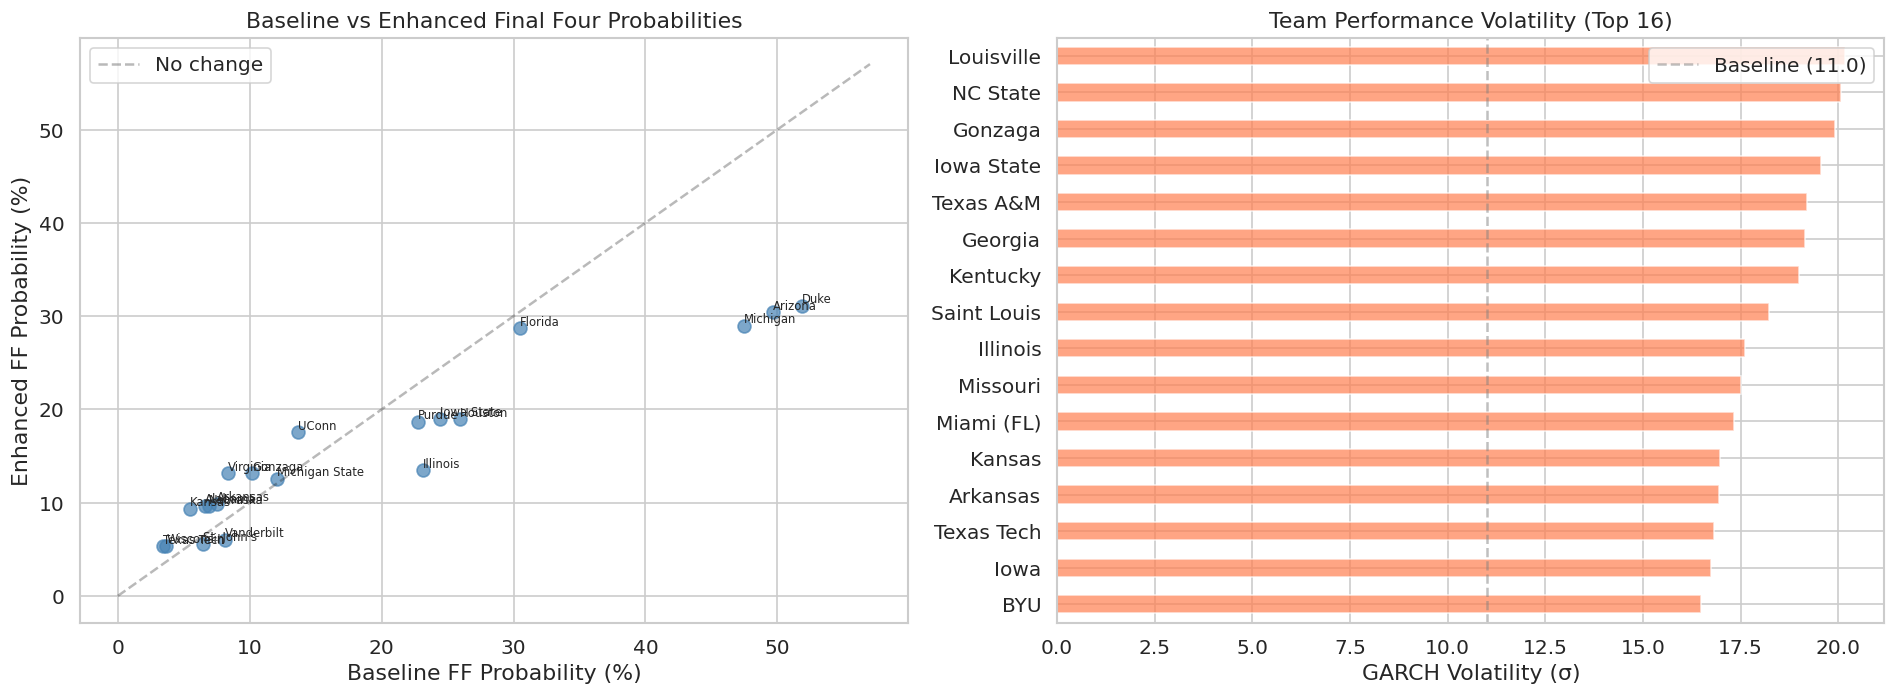

Saved: images/quant_analysis.png


In [15]:
if HAS_QUANT:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Left: Baseline vs Enhanced FF probabilities scatter
    if 'comparison' in dir() and comparison is not None:
        ax = axes[0]
        comp = comparison.head(20)
        ax.scatter(comp['Baseline_FF%'] * 100, comp['Enhanced_FF%'] * 100, 
                   c='steelblue', s=60, alpha=0.7)
        for _, row in comp.iterrows():
            ax.annotate(row['Team'], (row['Baseline_FF%']*100, row['Enhanced_FF%']*100),
                       fontsize=7, ha='left', va='bottom')
        max_val = max(comp['Baseline_FF%'].max(), comp['Enhanced_FF%'].max()) * 100 * 1.1
        ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.3, label='No change')
        ax.set_xlabel('Baseline FF Probability (%)')
        ax.set_ylabel('Enhanced FF Probability (%)')
        ax.set_title('Baseline vs Enhanced Final Four Probabilities')
        ax.legend()
    
    # Right: GARCH volatility bar chart (top 16 teams)
    if garch is not None and hasattr(garch, 'team_sigma'):
        ax = axes[1]
        vols = pd.Series(garch.team_sigma).sort_values(ascending=True).tail(16)
        vols.plot(kind='barh', ax=ax, color='coral', alpha=0.7)
        ax.set_xlabel('GARCH Volatility (σ)')
        ax.set_title('Team Performance Volatility (Top 16)')
        ax.axvline(x=11, color='gray', linestyle='--', alpha=0.5, label='Baseline (11.0)')
        ax.legend()
    
    plt.tight_layout()
    plt.savefig('images/quant_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: images/quant_analysis.png")

In [16]:
# --- PCA Diagnostic: 10-feature correlation analysis ---
feature_cols = ['n_NetRtg', 'n_ORtg', 'n_DRtg', 'n_NET']
feature_labels = ['NetRtg', 'ORtg', 'DRtg', 'NET']

if has_sor and 'n_SOR' in df.columns:
    feature_cols += ['n_SOR', 'n_WAB', 'n_NET_SOS']
    feature_labels += ['SOR', 'WAB', 'NET_SOS']
if has_q1 and 'n_Q1' in df.columns:
    feature_cols += ['n_Q1', 'n_Q1Q2']
    feature_labels += ['Q1%', 'Q1Q2%']
if has_injuries:
    feature_cols.append('n_InjHealth')
    feature_labels.append('InjHealth')

X = df[feature_cols].values
n_features = len(feature_cols)

# Standardize (zero mean, unit variance) for PCA on correlation matrix
X_std = (X - X.mean(axis=0)) / (X.std(axis=0) + 1e-10)

# Correlation matrix
corr = np.corrcoef(X_std, rowvar=False)

# Eigendecomposition (numpy.linalg.eigh for symmetric matrices)
eigenvalues, eigenvectors = np.linalg.eigh(corr)

# Sort by descending eigenvalue
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# Explained variance
total_var = eigenvalues.sum()
explained = eigenvalues / total_var
cumulative = np.cumsum(explained)

print(f'PCA on {n_features} composite features ({len(df)} teams)')
print(f'{"="*60}')
print(f'{"Component":<12} {"Eigenvalue":<12} {"Var %":<10} {"Cumulative %":<12}')
print(f'{"-"*60}')
for i in range(n_features):
    print(f'PC{i+1:<10} {eigenvalues[i]:>10.3f} {explained[i]:>9.1%} {cumulative[i]:>11.1%}')

print(f'\n{"="*60}')
print(f'PC1 and PC2 loadings:')
print(f'{"Feature":<12} {"PC1":<10} {"PC2":<10}')
print(f'{"-"*35}')
for j in range(n_features):
    print(f'{feature_labels[j]:<12} {eigenvectors[j, 0]:>8.3f} {eigenvectors[j, 1]:>8.3f}')

# Key insight
n_components_90 = int(np.searchsorted(cumulative, 0.90)) + 1
print(f'\n{n_components_90} components explain >= 90% of variance')
if has_injuries:
    inj_idx = feature_labels.index('InjHealth')
    print(f'InjHealth PC1 loading: {eigenvectors[inj_idx, 0]:.3f} '
          f'({"strong" if abs(eigenvectors[inj_idx, 0]) > 0.3 else "moderate" if abs(eigenvectors[inj_idx, 0]) > 0.15 else "weak"} contributor)')

PCA on 10 composite features (64 teams)
Component    Eigenvalue   Var %      Cumulative %
------------------------------------------------------------
PC1               7.622     76.2%       76.2%
PC2               0.993      9.9%       86.1%
PC3               0.556      5.6%       91.7%
PC4               0.390      3.9%       95.6%
PC5               0.190      1.9%       97.5%
PC6               0.132      1.3%       98.8%
PC7               0.062      0.6%       99.5%
PC8               0.050      0.5%       99.9%
PC9               0.005      0.1%      100.0%
PC10              0.000      0.0%      100.0%

PC1 and PC2 loadings:
Feature      PC1        PC2       
-----------------------------------
NetRtg          0.355   -0.043
ORtg            0.325   -0.023
DRtg            0.309   -0.057
NET             0.348   -0.024
SOR             0.344   -0.015
WAB            -0.344    0.027
NET_SOS         0.332    0.098
Q1%             0.303   -0.038
Q1Q2%           0.332   -0.036
InjHealth      -

## 7. Seed Constraint Optimization

Brute-force all 4-tuples (one per region, top 5 candidates each) to find the configuration
that maximizes probability-weighted composite score while satisfying seed sum >= 15.

In [17]:
# Top 5 candidates per region by FF probability
candidates = {}
for region in REGION_COLORS:
    region_df = df[df['Region'] == region].nlargest(5, 'FF_Prob')
    candidates[region] = region_df[['StdName', 'Seed', 'Composite', 'FF_Prob']].to_dict('records')

# Brute-force all valid combos
configs = []
for e, s, w, m in iterproduct(candidates['East'], candidates['South'],
                               candidates['West'], candidates['Midwest']):
    seed_sum = e['Seed'] + s['Seed'] + w['Seed'] + m['Seed']
    if seed_sum >= 15:
        total_comp = e['Composite'] + s['Composite'] + w['Composite'] + m['Composite']
        weighted = (e['Composite'] * e['FF_Prob'] + s['Composite'] * s['FF_Prob'] +
                    w['Composite'] * w['FF_Prob'] + m['Composite'] * m['FF_Prob'])
        configs.append({
            'East': e['StdName'], 'South': s['StdName'],
            'West': w['StdName'], 'Midwest': m['StdName'],
            'Seeds': f"{e['Seed']}+{s['Seed']}+{w['Seed']}+{m['Seed']}={seed_sum}",
            'Seed_Sum': seed_sum, 'Total_Composite': round(total_comp, 1),
            'Weighted_Score': round(weighted, 1),
            'E_Seed': e['Seed'], 'S_Seed': s['Seed'],
            'W_Seed': w['Seed'], 'M_Seed': m['Seed'],
        })

configs_df = pd.DataFrame(configs).sort_values('Weighted_Score', ascending=False)
print(f'Found {len(configs_df)} valid configurations (seed sum >= 15)\n')

print('Top 5 Configurations:')
print('=' * 85)
for idx, (_, row) in enumerate(configs_df.head(5).iterrows()):
    marker = ' <<<' if idx == 0 else ''
    print(f"#{idx+1}: {row['East']:>16} | {row['South']:>12} | {row['West']:>12} | {row['Midwest']:>12}")
    print(f"   Seeds: {row['Seeds']}   Composite: {row['Total_Composite']}   Weighted: {row['Weighted_Score']}{marker}")
    print()

# Select optimal
optimal = configs_df.iloc[0]
FINAL_FOUR = [optimal['East'], optimal['South'], optimal['West'], optimal['Midwest']]
FINAL_FOUR_SEEDS = {
    optimal['East']: int(optimal['E_Seed']), optimal['South']: int(optimal['S_Seed']),
    optimal['West']: int(optimal['W_Seed']), optimal['Midwest']: int(optimal['M_Seed']),
}

print('=' * 85)
print(f'OPTIMAL FINAL FOUR:  {" | ".join(FINAL_FOUR)}')
print(f'Seed Sum: {optimal["Seed_Sum"]}')

# Flag suspicious picks
print('\nPick Analysis:')
# Normalize SOS to percentile (higher = harder schedule) regardless of source
if has_sor:
    _sos_pctile = df['NET_SOS'].rank(ascending=True, pct=True)  # rank is inverted: low NET_SOS = hard
else:
    _sos_pctile = df['SOS_NetRtg'].rank(ascending=False, pct=True)  # rating: high = hard
for team in FINAL_FOUR:
    _match = df[df['StdName'] == team]
    row = _match.iloc[0]
    tidx = _match.index[0]
    flags = []
    if _sos_pctile.loc[tidx] < 0.25:
        flags.append('LOW SOS')
    if row['Conf'] not in ['ACC', 'B10', 'B12', 'SEC', 'BE']:
        flags.append('NON-POWER')
    pick_type = 'CHALK' if row['Seed'] <= 2 else ('DARK HORSE' if row['Seed'] >= 5 else 'MODERATE')
    flag_str = f'  [{", ".join(flags)}]' if flags else ''
    print(f'  ({int(row["Seed"])}) {team} - Composite: {row["Composite"]:.1f}, '
          f'FF Prob: {row["FF_Prob"]:.1%}, Type: {pick_type}{flag_str}')

Found 141 valid configurations (seed sum >= 15)

Top 5 Configurations:
#1:       St. John's |     Illinois |      Arizona |    Tennessee
   Seeds: 5+3+1+6=15   Composite: 300.2   Weighted: 68.1 <<<

#2:             Duke |     Illinois |    Wisconsin |    Tennessee
   Seeds: 1+3+5+6=15   Composite: 294.9   Weighted: 67.1

#3:   Michigan State |   Vanderbilt |      Arizona |    Tennessee
   Seeds: 3+5+1+6=15   Composite: 300.6   Weighted: 61.0

#4:             Duke |   Vanderbilt |      Gonzaga |    Tennessee
   Seeds: 1+5+3+6=15   Composite: 300.1   Weighted: 60.9

#5:             Duke |   Vanderbilt |     Arkansas |    Tennessee
   Seeds: 1+5+4+6=16   Composite: 296.8   Weighted: 58.6

OPTIMAL FINAL FOUR:  St. John's | Illinois | Arizona | Tennessee
Seed Sum: 15

Pick Analysis:
  (5) St. John's - Composite: 71.3, FF Prob: 6.4%, Type: DARK HORSE
  (3) Illinois - Composite: 74.5, FF Prob: 23.1%, Type: MODERATE
  (1) Arizona - Composite: 86.6, FF Prob: 49.7%, Type: CHALK  [LOW SOS]
  (6) 

## 8. Visualizations

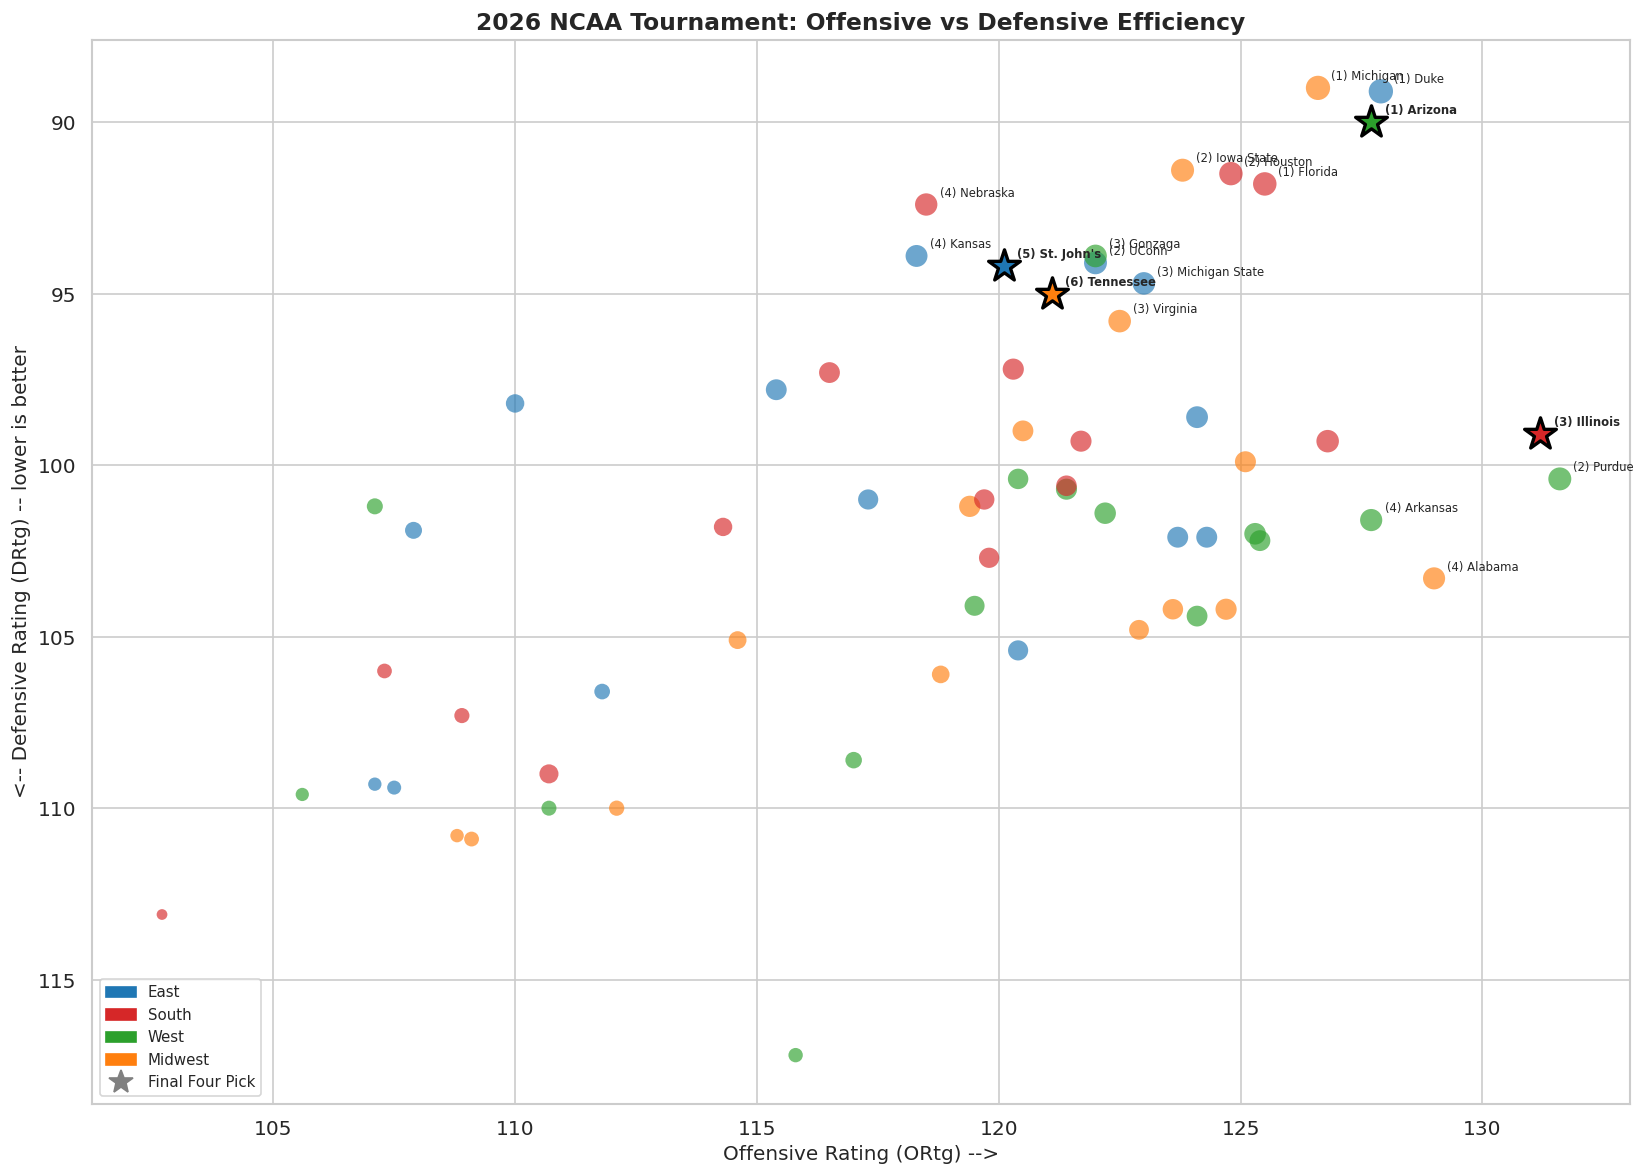

In [18]:
fig, ax = plt.subplots(figsize=(14, 10))

for _, row in df.iterrows():
    color = REGION_COLORS[row['Region']]
    is_ff = row['StdName'] in FINAL_FOUR
    size = 400 if is_ff else max(20, row['Composite'] * 2.5)
    marker = '*' if is_ff else 'o'
    ax.scatter(row['ORtg'], row['DRtg'], c=color, s=size, alpha=1.0 if is_ff else 0.65,
              marker=marker, edgecolors='black' if is_ff else 'none',
              linewidths=2 if is_ff else 0, zorder=10 if is_ff else 3)

# Label seeds 1-4 and Final Four picks
for _, row in df.iterrows():
    if row['Seed'] <= 4 or row['StdName'] in FINAL_FOUR:
        weight = 'bold' if row['StdName'] in FINAL_FOUR else 'normal'
        ax.annotate(f"({int(row['Seed'])}) {row['StdName']}", (row['ORtg'], row['DRtg']),
                   textcoords='offset points', xytext=(8, 5), fontsize=7, fontweight=weight)

ax.set_xlabel('Offensive Rating (ORtg) -->', fontsize=12)
ax.set_ylabel('<-- Defensive Rating (DRtg) -- lower is better', fontsize=12)
ax.invert_yaxis()
ax.set_title('2026 NCAA Tournament: Offensive vs Defensive Efficiency', fontsize=14, fontweight='bold')

handles = [mpatches.Patch(color=c, label=r) for r, c in REGION_COLORS.items()]
handles.append(Line2D([0], [0], marker='*', color='gray', markersize=15, linestyle='None', label='Final Four Pick'))
ax.legend(handles=handles, loc='lower left', fontsize=9)
plt.tight_layout()
plt.show()

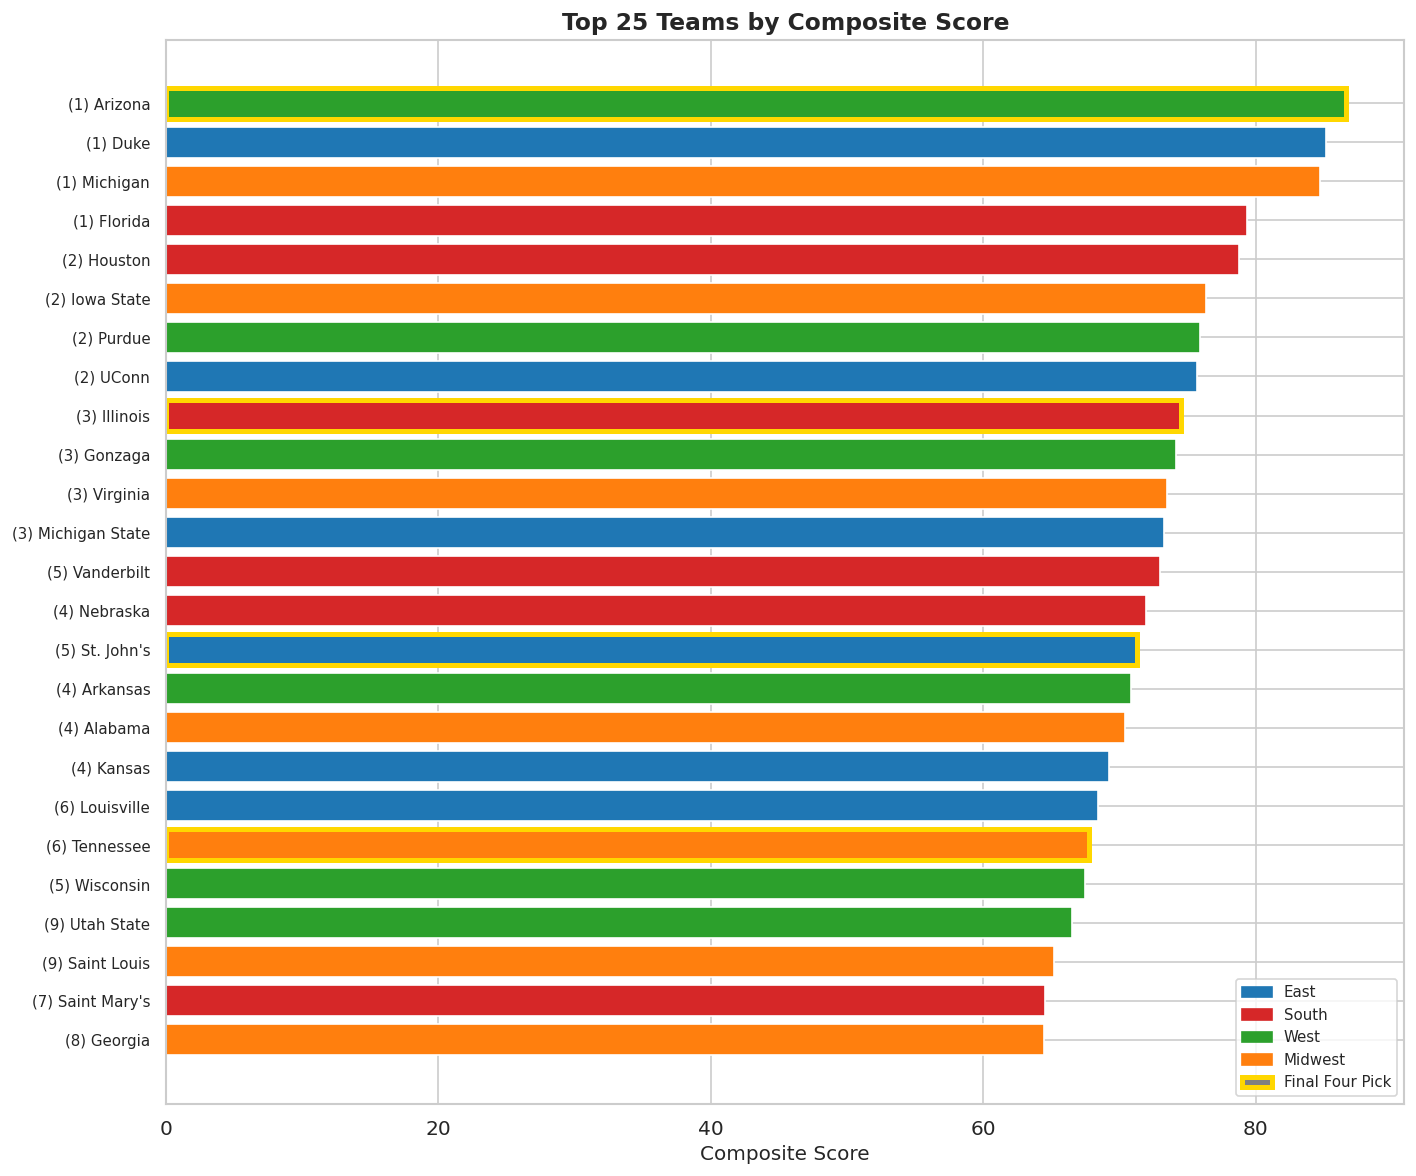

In [19]:
top25 = df.nlargest(25, 'Composite').sort_values('Composite')
fig, ax = plt.subplots(figsize=(12, 10))

colors = [REGION_COLORS[r] for r in top25['Region']]
bars = ax.barh(range(len(top25)), top25['Composite'], color=colors, edgecolor='white')

for i, (_, row) in enumerate(top25.iterrows()):
    if row['StdName'] in FINAL_FOUR:
        bars[i].set_edgecolor('gold')
        bars[i].set_linewidth(3)

ax.set_yticks(range(len(top25)))
ax.set_yticklabels([f"({int(r['Seed'])}) {r['StdName']}" for _, r in top25.iterrows()], fontsize=9)
ax.set_xlabel('Composite Score', fontsize=12)
ax.set_title('Top 25 Teams by Composite Score', fontsize=14, fontweight='bold')

handles = [mpatches.Patch(color=c, label=r) for r, c in REGION_COLORS.items()]
handles.append(mpatches.Patch(facecolor='gray', edgecolor='gold', linewidth=3, label='Final Four Pick'))
ax.legend(handles=handles, loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

In [20]:
from IPython.display import display, HTML

for region in REGION_COLORS:
    region_df = df[df['Region'] == region].nlargest(6, 'Composite')

    cols = ['Seed', 'StdName', 'Composite', 'Rk', 'NetRtg', 'ORtg', 'DRtg', 'NET_Rank', 'FF_Prob']
    if has_sor:
        cols.insert(8, 'SOR')
        cols.insert(9, 'WAB')
    if has_quad and 'Q1_W' in df.columns:
        cols.insert(-1, 'Q1_W')
        cols.insert(-1, 'Q1_L')

    tbl = region_df[cols].copy()
    rename_map = {'StdName': 'Team', 'Rk': 'KP#', 'NET_Rank': 'NET#', 'FF_Prob': 'FF%'}
    tbl = tbl.rename(columns=rename_map)

    tbl['FF%'] = tbl['FF%'].apply(lambda x: f'{x:.1%}')
    tbl['Composite'] = tbl['Composite'].round(1)
    tbl['NET#'] = tbl['NET#'].astype(int)
    if 'Q1_W' in tbl.columns and 'Q1_L' in tbl.columns:
        tbl['Q1'] = tbl.apply(lambda r: f"{int(r['Q1_W'])}-{int(r['Q1_L'])}" if pd.notna(r['Q1_W']) else '-', axis=1)
        tbl = tbl.drop(columns=['Q1_W', 'Q1_L'])
    tbl = tbl.reset_index(drop=True)

    def highlight_ff(row):
        if row['Team'] in FINAL_FOUR:
            return ['background-color: #ffffcc; font-weight: bold'] * len(row)
        return [''] * len(row)

    color = REGION_COLORS[region]
    styled = (tbl.style
              .apply(highlight_ff, axis=1)
              .set_caption(f'{region} Region')
              .set_properties(**{'text-align': 'center'})
              .set_table_styles([{'selector': 'caption',
                                  'props': [('font-size', '14px'), ('font-weight', 'bold'),
                                            ('color', color)]}]))
    display(styled)
    print()

,Seed,Team,Composite,KP#,NetRtg,ORtg,DRtg,NET#,SOR,WAB,FF%,Q1
0,1,Duke,85.200000,1,38.900000,127.900000,89.100000,1,3,2,51.8%,17-2
1,2,UConn,75.700000,11,27.850000,122.000000,94.100000,10,4,7,13.7%,7-3
2,3,Michigan State,73.200000,9,28.300000,123.000000,94.700000,11,13,12,12.1%,10-6
3,5,St. John's,71.300000,17,25.890000,120.100000,94.200000,16,16,14,6.4%,5-5
4,4,Kansas,69.200000,21,24.410000,118.300000,93.900000,21,18,16,5.5%,9-9
5,6,Louisville,68.400000,19,25.420000,124.100000,98.600000,17,26,24,5.3%,8-10


,Seed,Team,Composite,KP#,NetRtg,ORtg,DRtg,NET#,SOR,WAB,FF%,Q1
0,1,Florida,79.400000,4,33.780000,125.500000,91.800000,4,5,6,30.5%,12-6
1,2,Houston,78.700000,5,33.390000,124.800000,91.500000,5,6,5,25.9%,10-6
2,3,Illinois,74.500000,7,32.090000,131.200000,99.100000,8,17,18,23.1%,7-8
3,5,Vanderbilt,72.900000,12,27.500000,126.800000,99.300000,13,12,10,8.1%,10-7
4,4,Nebraska,72.000000,14,26.150000,118.500000,92.400000,14,10,13,6.9%,9-6
5,7,Saint Mary's,64.500000,24,23.080000,120.300000,97.200000,22,30,30,1.8%,1-4


,Seed,Team,Composite,KP#,NetRtg,ORtg,DRtg,NET#,SOR,WAB,FF%,Q1
0,1,Arizona,86.600000,2,37.620000,127.700000,90.000000,3,1,3,49.7%,16-2
1,2,Purdue,75.900000,8,31.190000,131.600000,100.400000,9,7,4,22.8%,11-8
2,3,Gonzaga,74.200000,10,28.100000,122.000000,93.900000,7,11,17,10.2%,7-2
3,4,Arkansas,70.900000,15,26.040000,127.700000,101.600000,15,8,11,7.5%,8-8
4,5,Wisconsin,67.500000,22,23.380000,125.300000,102.000000,25,19,20,3.7%,9-8
5,9,Utah State,66.500000,30,20.780000,122.200000,101.400000,26,34,31,1.1%,4-4


,Seed,Team,Composite,KP#,NetRtg,ORtg,DRtg,NET#,SOR,WAB,FF%,Q1
0,1,Michigan,84.700000,3,37.580000,126.600000,89.000000,2,2,1,47.5%,17-3
1,2,Iowa State,76.300000,6,32.380000,123.800000,91.400000,6,14,9,24.4%,8-7
2,3,Virginia,73.500000,13,26.710000,122.500000,95.800000,12,9,8,8.4%,8-4
3,4,Alabama,70.400000,18,25.700000,129.000000,103.300000,18,15,15,6.6%,7-7
4,6,Tennessee,67.800000,16,26.020000,121.100000,95.000000,20,22,23,4.8%,6-10
5,9,Saint Louis,65.200000,41,18.260000,119.400000,101.200000,31,38,41,0.7%,2-1


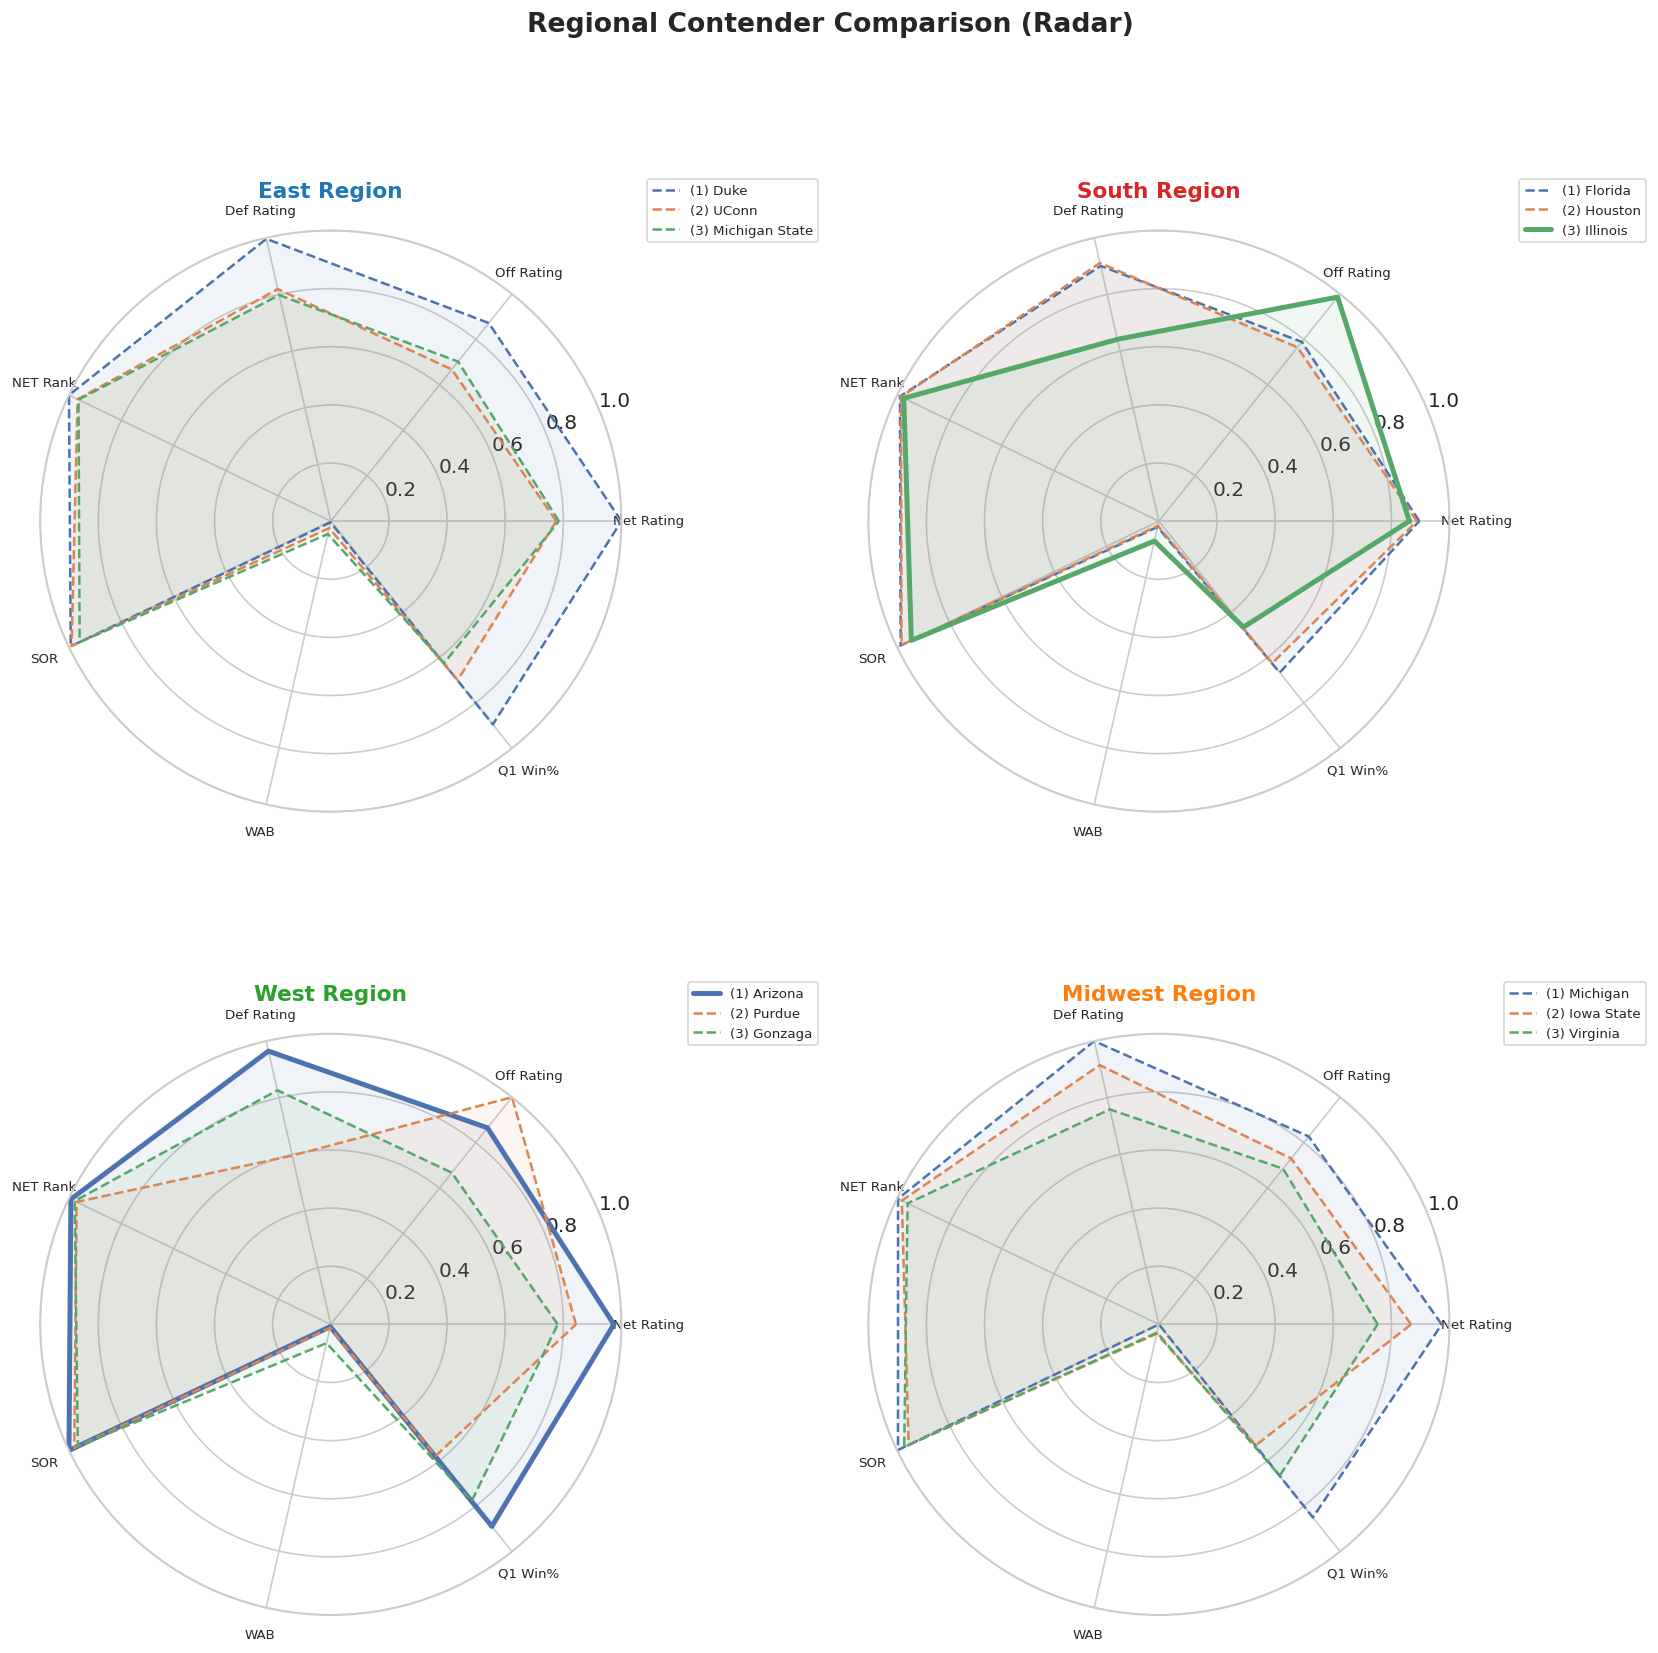

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 14), subplot_kw=dict(polar=True))

radar_metrics = ['n_NetRtg', 'n_ORtg', 'n_DRtg', 'n_NET']
radar_labels = ['Net Rating', 'Off Rating', 'Def Rating', 'NET Rank']

if has_sor and 'n_SOR' in df.columns:
    radar_metrics += ['n_SOR', 'n_WAB']
    radar_labels += ['SOR', 'WAB']

if has_quad and 'n_Q1' in df.columns:
    radar_metrics.append('n_Q1')
    radar_labels.append('Q1 Win%')

n_met = len(radar_metrics)
angles = np.linspace(0, 2 * np.pi, n_met, endpoint=False).tolist()
angles += angles[:1]

for ax, region in zip(axes.flat, REGION_COLORS):
    region_top = df[df['Region'] == region].nlargest(3, 'Composite')

    for _, row in region_top.iterrows():
        values = [row[m] / 100 for m in radar_metrics]
        values += values[:1]
        is_ff = row['StdName'] in FINAL_FOUR
        label = f"({int(row['Seed'])}) {row['StdName']}"
        lw = 3 if is_ff else 1.5
        ls = '-' if is_ff else '--'
        ax.plot(angles, values, linewidth=lw, linestyle=ls, label=label)
        ax.fill(angles, values, alpha=0.08)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_labels, size=8)
    ax.set_ylim(0, 1)
    ax.set_title(f'{region} Region', size=13, fontweight='bold',
                color=REGION_COLORS[region], pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=8)

plt.suptitle('Regional Contender Comparison (Radar)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

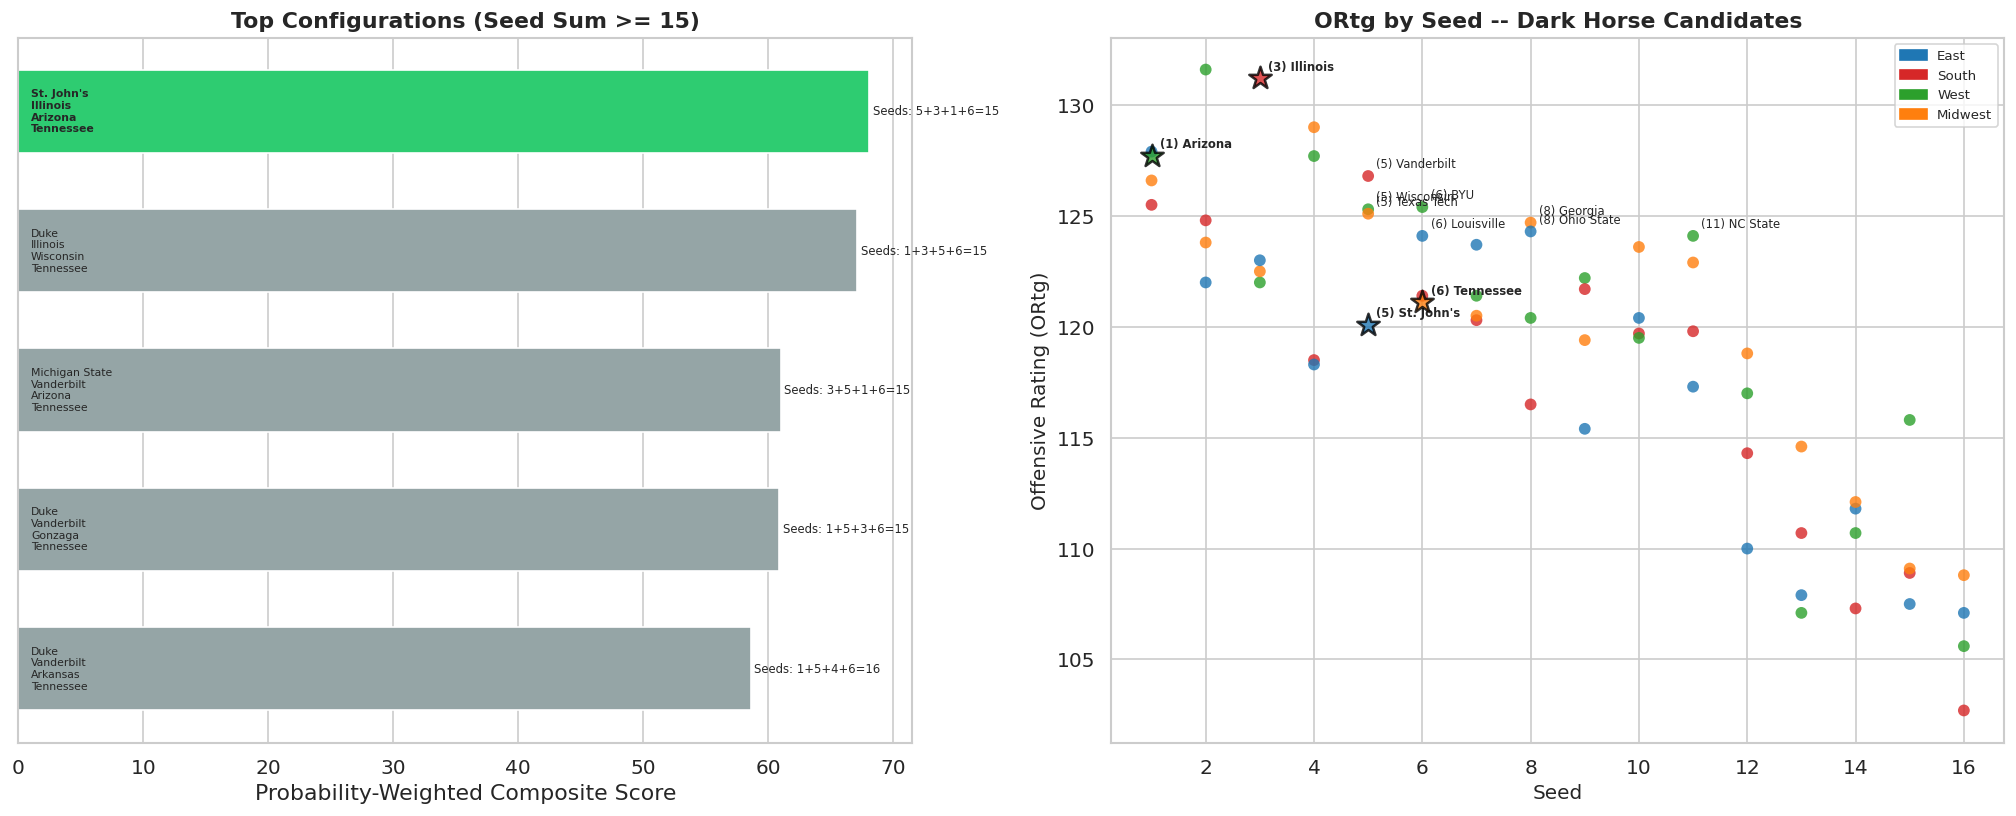

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 7))

# --- Left: Seed Constraint Configurations ---
top_cfgs = configs_df.head(5).reset_index(drop=True)
bar_colors = ['#2ecc71' if i == 0 else '#95a5a6' for i in range(len(top_cfgs))]

for i, (_, cfg) in enumerate(top_cfgs.iterrows()):
    teams_label = f"{cfg['East']}\n{cfg['South']}\n{cfg['West']}\n{cfg['Midwest']}"
    ax1.barh(i, cfg['Weighted_Score'], color=bar_colors[i], edgecolor='white', height=0.6)
    ax1.text(cfg['Weighted_Score'] + 0.3, i, f"Seeds: {cfg['Seeds']}", va='center', fontsize=7)
    ax1.text(1, i, teams_label, va='center', fontsize=6.5,
             fontweight='bold' if i == 0 else 'normal')

ax1.set_xlabel('Probability-Weighted Composite Score')
ax1.set_title('Top Configurations (Seed Sum >= 15)', fontweight='bold')
ax1.set_yticks([])
ax1.invert_yaxis()

# --- Right: ORtg vs Seed ---
for _, row in df.iterrows():
    color = REGION_COLORS[row['Region']]
    is_ff = row['StdName'] in FINAL_FOUR
    marker = '*' if is_ff else 'o'
    size = 200 if is_ff else 50
    ax2.scatter(row['Seed'], row['ORtg'], c=color, s=size, marker=marker,
               edgecolors='black' if is_ff else 'none',
               linewidths=1.5 if is_ff else 0, alpha=0.8, zorder=10 if is_ff else 3)

# Label FF picks + high-ORtg upsets
ortg_q75 = df['ORtg'].quantile(0.75)
for _, row in df.iterrows():
    if row['StdName'] in FINAL_FOUR or (row['Seed'] >= 5 and row['ORtg'] >= ortg_q75):
        ax2.annotate(f"({int(row['Seed'])}) {row['StdName']}", (row['Seed'], row['ORtg']),
                    textcoords='offset points', xytext=(5, 5), fontsize=7,
                    fontweight='bold' if row['StdName'] in FINAL_FOUR else 'normal')

ax2.set_xlabel('Seed', fontsize=12)
ax2.set_ylabel('Offensive Rating (ORtg)', fontsize=12)
ax2.set_title('ORtg by Seed -- Dark Horse Candidates', fontweight='bold')
handles = [mpatches.Patch(color=c, label=r) for r, c in REGION_COLORS.items()]
ax2.legend(handles=handles, fontsize=8)

plt.tight_layout()
plt.show()

### Injury Impact Dashboard

Visualize how injuries affect team ratings and composite rankings.

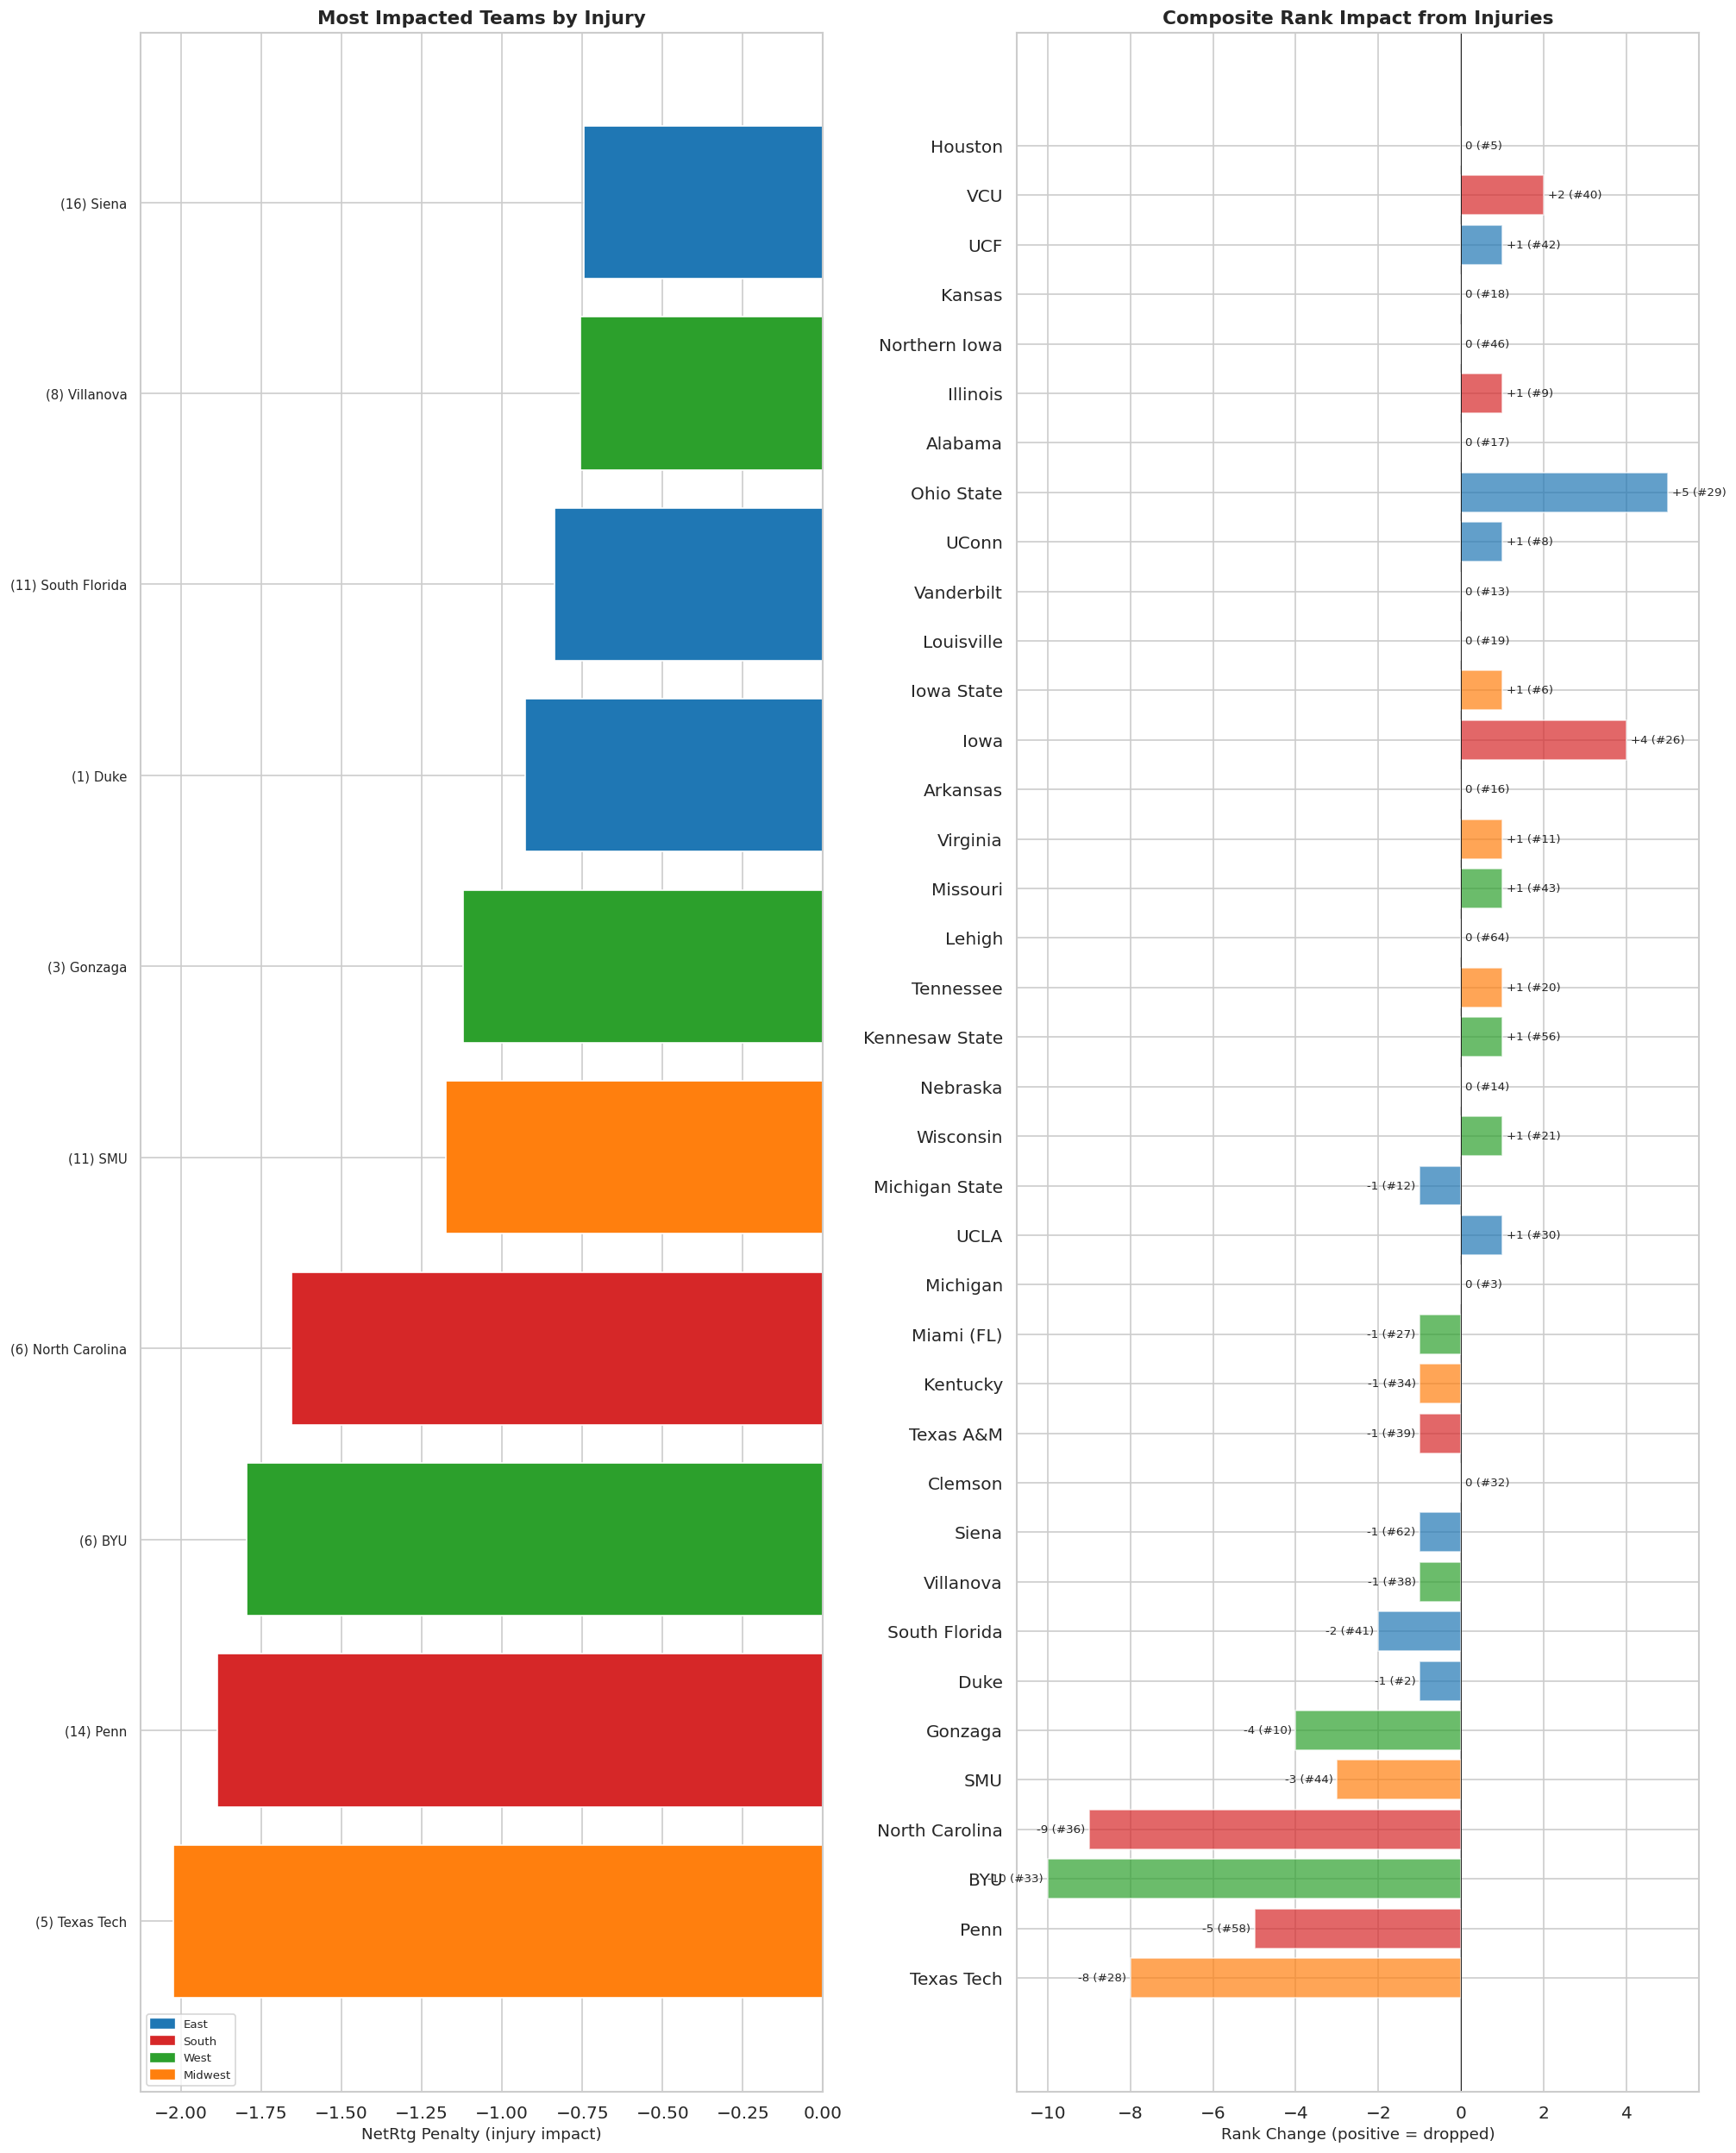


Injury Impact Summary:
Team                 Seed  Injuries  Penalty    Orig NetRtg  Adj NetRtg  Health   Key Injuries
--------------------------------------------------------------------------------------------------------------
Texas Tech           5     1           -2.024       25.20       23.18     0.0  Jt Toppin (Out, -2.02)
Penn                 14    5           -1.887        1.33       -0.56     6.8  Ethan Roberts (Out, -1.45); Dylan Williams (Questi...
BYU                  6     4           -1.796       23.21       21.41    11.3  Nate Pickens (Out, -0.08); Dawson Baker (Out, -0.3...
North Carolina       6     3           -1.655       20.83       19.18    18.2  Ivan Matlekovic (Questionable, -0.00); James Brown...
SMU                  11    1           -1.174       18.08       16.91    42.0  B J Edwards (Out, -1.17)
Gonzaga              3     1           -1.122       28.10       26.98    44.6  Braden Huff (Out, -1.12)
Duke                 1     3           -0.928       38.90    

In [23]:
# --- Injury Impact Dashboard ---
if has_injuries and df['total_penalty'].abs().max() > 0:
    injured_df = df[df['total_penalty'] != 0].sort_values('total_penalty')

    fig, axes = plt.subplots(1, 2, figsize=(17, max(6, len(injured_df) * 0.5 + 2)))

    # --- Left: Horizontal bar chart of top 10 most-impacted teams ---
    ax1 = axes[0]
    top_impacted = injured_df.head(10).sort_values('total_penalty')
    colors = [REGION_COLORS.get(r, '#888888') for r in top_impacted['Region']]
    bars = ax1.barh(range(len(top_impacted)), top_impacted['total_penalty'], color=colors, edgecolor='white')

    ax1.set_yticks(range(len(top_impacted)))
    ax1.set_yticklabels([f"({int(r['Seed'])}) {r['StdName']}" for _, r in top_impacted.iterrows()], fontsize=9)
    ax1.set_xlabel('NetRtg Penalty (injury impact)', fontsize=11)
    ax1.set_title('Most Impacted Teams by Injury', fontsize=13, fontweight='bold')
    ax1.axvline(x=0, color='black', linewidth=0.5)

    handles = [mpatches.Patch(color=c, label=r) for r, c in REGION_COLORS.items()]
    ax1.legend(handles=handles, fontsize=8, loc='lower left')

    # --- Right: Before/after composite rank comparison ---
    ax2 = axes[1]

    # Compute what composite rank would be without injuries
    df_temp = df.copy()
    # Recalculate composite without injury feature for comparison
    if 'n_InjHealth' in df.columns:
        old_composite = df['Composite'] - 0.05 * df['n_InjHealth'] + 0.05 * 100  # As if all healthy
        old_ranks = old_composite.rank(ascending=False).astype(int)
    else:
        old_ranks = df['CompRank']

    for _, row in injured_df.iterrows():
        team = row['StdName']
        new_rank = row['CompRank']
        old_rank = old_ranks.loc[df['StdName'] == team].values[0]
        delta = old_rank - new_rank  # positive = improved rank (moved up)

        color = REGION_COLORS.get(row['Region'], '#888888')
        ax2.barh(team, delta, color=color, alpha=0.7)
        direction = '+' if delta > 0 else ''
        ax2.text(delta + (0.1 if delta >= 0 else -0.1), team,
                f'{direction}{delta} (#{new_rank})', va='center', fontsize=8,
                ha='left' if delta >= 0 else 'right')

    ax2.set_xlabel('Rank Change (positive = dropped)', fontsize=11)
    ax2.set_title('Composite Rank Impact from Injuries', fontsize=13, fontweight='bold')
    ax2.axvline(x=0, color='black', linewidth=0.5)

    plt.tight_layout()
    plt.show()

    # --- Injury summary table ---
    print('\nInjury Impact Summary:')
    print(f'{"Team":<20} {"Seed":<5} {"Injuries":<9} {"Penalty":<10} {"Orig NetRtg":<12} {"Adj NetRtg":<11} {"Health":<8} {"Key Injuries"}')
    print('-' * 110)
    for _, row in injured_df.iterrows():
        orig = row['NetRtg']
        adj = row['adjusted_NetRtg']
        summary = row['key_injuries_summary'][:50] + ('...' if len(str(row['key_injuries_summary'])) > 50 else '')
        print(f'{row["StdName"]:<20} {int(row["Seed"]):<5} {int(row["num_injuries"]):<9} '
              f'{row["total_penalty"]:>+8.3f}  {orig:>10.2f}  {adj:>10.2f}  '
              f'{row["n_InjHealth"]:>6.1f}  {summary}')

    # --- Marquee injury callout ---
    marquee = injured_df[injured_df['total_penalty'].abs() > 1.0]
    if len(marquee) > 0:
        print(f'\n{"="*80}')
        print('MARQUEE INJURIES (penalty > 1.0 NetRtg points):')
        for _, row in marquee.iterrows():
            print(f'  {row["StdName"]} ({int(row["Seed"])}-seed, {row["Region"]}): '
                  f'penalty={row["total_penalty"]:+.3f}')
            if row['key_injuries_summary']:
                print(f'    Injuries: {row["key_injuries_summary"]}')
        print(f'{"="*80}')
else:
    print('No injury data available or no teams have injury penalties.')
    print('Run: python scripts/scrape_injuries.py && python scripts/scrape_player_stats.py')

## 9. Essay Bullet Points & Summary

Per-pick statistical breakdown and two essay draft structures (per-team paragraphs & cohesive narrative).

In [24]:
print('=' * 85)
print('FINAL FOUR PICKS -- DETAILED BREAKDOWN')
print('=' * 85)

for team_name in FINAL_FOUR:
    row = df[df['StdName'] == team_name].iloc[0]
    region = row['Region']
    seed = int(row['Seed'])
    pick_type = 'Chalk' if seed <= 2 else ('Dark Horse' if seed >= 5 else 'Moderate upset')

    print(f'\n--- ({seed}) {team_name} -- {region} Region [{pick_type}] ---')
    print(f'  KenPom Rank: #{int(row["Rk"])}  |  NET Rank: #{int(row["NET_Rank"])}')
    print(f'  ORtg: {row["ORtg"]:.1f} (#{row["ORtg_Rank"]} in field)  |  DRtg: {row["DRtg"]:.1f} (#{row["DRtg_Rank"]} in field)')
    print(f'  NetRtg: {row["NetRtg"]:.2f}  |  SOS: {row["SOS_NetRtg"]:.2f}')
    if has_sor and pd.notna(row.get('SOR')):
        print(f'  SOR: #{int(row["SOR"])}  |  WAB: {row["WAB"]:.0f}  |  KPI: #{int(row["KPI"])}  |  BPI: #{int(row["BPI"])}')
    if has_quad and 'Q1_W' in df.columns and pd.notna(row.get('Q1_W')):
        print(f'  Q1 Record: {int(row["Q1_W"])}-{int(row["Q1_L"])} ({row["Q1_WinPct"]:.1%})')
    print(f'  Final Four Probability: {row["FF_Prob"]:.1%}')
    print(f'  Composite Score: {row["Composite"]:.1f} (#{int(row["CompRank"])} in field)')

seed_sum = sum(FINAL_FOUR_SEEDS.values())
print(f'\n{"=" * 85}')
seeds_str = ' + '.join(str(FINAL_FOUR_SEEDS[t]) for t in FINAL_FOUR)
print(f'SEED SUM: {seeds_str} = {seed_sum}')
print(f'{"=" * 85}')

# --- Thesis ---
print('\n\nTHESIS STATEMENT:')
print('My Final Four is built on a composite model weighing offensive efficiency,')
print('defensive quality, schedule strength, and NET rankings -- optimized under')
print(f'the seed-sum constraint (>= 15) via {N_SIMS:,}-iteration Monte Carlo bracket simulation.')

# --- Draft 1: Per-team paragraphs ---
print('\n\n' + '=' * 85)
print('ESSAY DRAFT 1: Per-Team Paragraphs (~200 words)')
print('=' * 85 + '\n')

for team_name in FINAL_FOUR:
    row = df[df['StdName'] == team_name].iloc[0]
    seed = int(row['Seed'])
    region = row['Region']
    sor_str = f', SOR #{int(row["SOR"])}' if has_sor and pd.notna(row.get('SOR')) else ''
    wab_str = f', WAB {row["WAB"]:.0f}' if has_sor and pd.notna(row.get('WAB')) else ''
    para = (f'{team_name} ({seed}-seed, {region}): Ranked #{int(row["Rk"])} in KenPom '
            f'and #{int(row["NET_Rank"])} in NET '
            f'with an offensive rating of {row["ORtg"]:.1f} (#{row["ORtg_Rank"]} in the tournament field), '
            f'{team_name} {"is a dominant force" if seed <= 2 else "is a data-backed upset pick"}. '
            f'Their net efficiency of {row["NetRtg"]:.1f}{sor_str}{wab_str} '
            f'confirm they have been tested against elite competition. '
            f'My simulation gives them a {row["FF_Prob"]:.0%} chance of reaching the Final Four.')
    if team_name == 'Duke':
        para += (' One caveat: starting point guard Caleb Foster is out with a right foot fracture '
                 'suffered March 7. Cayden Boozer has stepped into a larger role and performed well '
                 'through the ACC Tournament, but these efficiency numbers reflect a full-strength roster '
                 '-- making Duke my highest-upside but also highest-variance pick.')
    print(para + '\n')

# --- Draft 2: Cohesive narrative ---
print('\n' + '=' * 85)
print('ESSAY DRAFT 2: Cohesive Narrative (~200 words)')
print('=' * 85 + '\n')

chalk = [t for t in FINAL_FOUR if FINAL_FOUR_SEEDS[t] <= 2]
moderate = [t for t in FINAL_FOUR if 3 <= FINAL_FOUR_SEEDS[t] <= 4]
dark_horses = [t for t in FINAL_FOUR if FINAL_FOUR_SEEDS[t] >= 5]

parts = []
parts.append('My Final Four selections are driven by a composite analytical model that '
             'weighs KenPom efficiency ratings, real NCAA NET rankings, Strength of Record (SOR), '
             'Wins Above Bubble (WAB), and quad record performance -- blending predictive efficiency '
             'metrics with the resume-based measures the selection committee actually uses.')

if chalk:
    chalk_str = ' and '.join(chalk)
    parts.append(f'{chalk_str} {"anchors" if len(chalk) == 1 else "anchor"} my bracket '
                 f'as {"a top-tier squad" if len(chalk) == 1 else "top-tier squads"} with '
                 f'dominant efficiency profiles and favorable paths to the Final Four.')
    if 'Duke' in chalk:
        parts.append('A key risk factor: Duke will be without starting point guard Caleb Foster '
                     '(right foot fracture) for likely the entire tournament. '
                     'While Cayden Boozer has filled in capably, my model reflects full-strength '
                     'season numbers, so Duke carries more variance than the raw composite suggests.')

if moderate:
    for t in moderate:
        r = df[df['StdName'] == t].iloc[0]
        parts.append(f'{t} ({int(r["Seed"])}-seed) is a calculated moderate upset: '
                     f'ranked #{int(r["Rk"])} in KenPom with a {r["ORtg"]:.1f} offensive rating '
                     f'(#{r["ORtg_Rank"]} in the field), their efficiency metrics suggest '
                     f'they are significantly underseeded and primed for a deep run.')

if dark_horses:
    for t in dark_horses:
        r = df[df['StdName'] == t].iloc[0]
        parts.append(f'{t} ({int(r["Seed"])}-seed) is a data-driven dark horse: '
                     f'ranked #{int(r["Rk"])} in KenPom with a net rating of {r["NetRtg"]:.1f} '
                     f'and strength of schedule of {r["SOS_NetRtg"]:.1f}, they outperform '
                     f'their seed in every advanced metric.')

parts.append(f'With a seed sum of {seed_sum}, this configuration satisfies the constraint '
             f'while maximizing composite quality. Each pick was validated through a '
             f'{N_SIMS:,}-iteration Monte Carlo simulation that accounts for bracket path '
             f'difficulty, matchup variance, and the inherent unpredictability that makes '
             f'March Madness compelling.')

narrative = '\n\n'.join(parts)
words = narrative.split()
print(narrative)
print(f'\n(Word count: {len(words)})')

FINAL FOUR PICKS -- DETAILED BREAKDOWN

--- (5) St. John's -- East Region [Dark Horse] ---
  KenPom Rank: #17  |  NET Rank: #16
  ORtg: 120.1 (#35 in field)  |  DRtg: 94.2 (#11 in field)
  NetRtg: 25.89  |  SOS: 11.51
  SOR: #16  |  WAB: 14  |  KPI: #10  |  BPI: #16
  Q1 Record: 5-5 (50.0%)
  Final Four Probability: 6.4%
  Composite Score: 71.3 (#15 in field)

--- (3) Illinois -- South Region [Moderate upset] ---
  KenPom Rank: #7  |  NET Rank: #8
  ORtg: 131.2 (#2 in field)  |  DRtg: 99.1 (#21 in field)
  NetRtg: 32.09  |  SOS: 13.64
  SOR: #17  |  WAB: 18  |  KPI: #19  |  BPI: #7
  Q1 Record: 7-8 (46.7%)
  Final Four Probability: 23.1%
  Composite Score: 74.5 (#9 in field)

--- (1) Arizona -- West Region [Chalk] ---
  KenPom Rank: #2  |  NET Rank: #3
  ORtg: 127.7 (#5 in field)  |  DRtg: 90.0 (#3 in field)
  NetRtg: 37.62  |  SOS: 14.94
  SOR: #1  |  WAB: 3  |  KPI: #2  |  BPI: #3
  Q1 Record: 16-2 (88.9%)
  Final Four Probability: 49.7%
  Composite Score: 86.6 (#1 in field)

--- (6)

## 10. Unconstrained EV-Optimized Bracket

Remove all seed constraints and optimize purely for **expected ESPN fantasy points** with a **contrarian leverage layer**.

- **No historical prior blending** — pure model win probabilities from KenPom + GARCH + HMM
- **Per-slot EV** — each game scored by `P(correct) × round_points`
- **Contrarian leverage** — upweight high-EV picks that the public is fading

| Round | ESPN Points |
|-------|:-----------:|
| Round of 64 | 10 |
| Round of 32 | 20 |
| Sweet 16 | 40 |
| Elite 8 | 80 |
| Final Four | 160 |
| Championship | 320 |

In [25]:
# --- Section 10: EV-Optimized Bracket Setup ---
LEVERAGE_WEIGHT = 1.0  # 0.0 = pure EV, 2.0 = aggressive contrarian

if HAS_QUANT:
    print("Configuring EV-Optimized Simulator (unconstrained)...")
    print(f"  Leverage weight: {LEVERAGE_WEIGHT}")
    print(f"  Simulations: 10,000")
    print(f"  Prior blending: DISABLED (pure model probabilities)")
    print()

    ev_sim = EVOptimizedSimulator(
        bracket=bracket, df=df,
        garch=garch, hmm=hmm, kalman=kalman,
        n_sims=10000, leverage_weight=LEVERAGE_WEIGHT,
    )
    ev_results = ev_sim.run()

    print(f"Total EV (pure): {ev_results['total_ev']:.1f} expected points")
    print(f"Total EV (leverage-adjusted): {ev_results['total_leverage_ev']:.1f}")
    print(f"Predicted champion: {ev_results['champion']}")
else:
    print("Quantitative models not available — skipping EV optimization")

Configuring EV-Optimized Simulator (unconstrained)...
  Leverage weight: 1.0
  Simulations: 10,000
  Prior blending: DISABLED (pure model probabilities)

Total EV (pure): 722.8 expected points
Total EV (leverage-adjusted): 826.2
Predicted champion: Duke


In [26]:
# --- Full 63-Game EV-Optimized Bracket ---
if HAS_QUANT:
    print("=" * 70)
    print("FULL 63-GAME BRACKET (EV-Optimized, No Constraints)")
    print("=" * 70)

    round_names = ['Round of 64', 'Round of 32', 'Sweet 16',
                   'Elite 8', 'Final Four', 'Championship']

    total_games = 0
    for round_name in round_names:
        if round_name in ev_results['ev_bracket']:
            games = ev_results['ev_bracket'][round_name]
            pts = EVOptimizedSimulator.ROUND_POINTS[round_name]
            print(f"\n--- {round_name} ({pts} pts each) ---")
            for game in games:
                upset = " UPSET" if game.get('upset', False) else ""
                print(f"  ({game['winner_seed']}) {game['winner']:<20s} over "
                      f"({game['loser_seed']}) {game['loser']:<20s} "
                      f"[{game['win_prob']:.1%}] EV={game['ev']:.1f}{upset}")
                total_games += 1

    print(f"\nTotal games: {total_games}")
    print(f"Predicted champion: {ev_results['champion']}")

FULL 63-GAME BRACKET (EV-Optimized, No Constraints)

--- Round of 64 (10 pts each) ---
  (1) Duke                 over (16) Siena                [93.2%] EV=9.3
  (2) UConn                over (15) Furman               [85.4%] EV=8.5
  (3) Michigan State       over (14) North Dakota State   [77.5%] EV=7.8
  (5) St. John's           over (12) Northern Iowa        [71.2%] EV=7.1
  (4) Kansas               over (13) Cal Baptist          [69.8%] EV=7.0
  (7) UCLA                 over (10) UCF                  [61.9%] EV=6.2
  (6) Louisville           over (11) South Florida        [60.4%] EV=6.0
  (8) Ohio State           over (9) TCU                  [55.9%] EV=5.6
  (1) Michigan             over (16) UMBC                 [87.7%] EV=8.8
  (2) Iowa State           over (15) Tennessee State      [83.9%] EV=8.4
  (3) Virginia             over (14) Wright State         [81.7%] EV=8.2
  (4) Alabama              over (13) Hofstra              [72.9%] EV=7.3
  (5) Texas Tech           over (12) A

In [27]:
# --- Leverage-Adjusted Picks (contrarian layer) ---
if HAS_QUANT:
    print("=" * 70)
    print("LEVERAGE-ADJUSTED PICKS (contrarian overlay)")
    print(f"Weight = {LEVERAGE_WEIGHT} | leverage_ev = ev * (1 + w * (1 - ownership))")
    print("=" * 70)

    # Build EV lookup keyed by (round, region, loser) for O(1) diff detection
    ev_by_slot = {}
    for round_name in round_names:
        for g in ev_results['ev_bracket'].get(round_name, []):
            ev_by_slot[(round_name, g['region'], g['loser'])] = g['winner']

    n_contrarian = 0
    for round_name in round_names:
        lev_games = ev_results['leverage_bracket'].get(round_name, [])
        if lev_games:
            print(f"\n--- {round_name} ---")
            for lg in lev_games:
                own_pct = lg.get('ownership', 0)
                ev_winner = ev_by_slot.get((round_name, lg['region'], lg['loser']))
                marker = ""
                if ev_winner and ev_winner != lg['winner']:
                    marker = " << CONTRARIAN"
                    n_contrarian += 1
                print(f"  ({lg['winner_seed']}) {lg['winner']:<20s} "
                      f"EV={lg['ev']:.1f} Own={own_pct:.0%} "
                      f"LevEV={lg['leverage_ev']:.1f}{marker}")

    print(f"\nTotal contrarian flips: {n_contrarian}")

LEVERAGE-ADJUSTED PICKS (contrarian overlay)
Weight = 1.0 | leverage_ev = ev * (1 + w * (1 - ownership))

--- Round of 64 ---
  (5) St. John's           EV=7.1 Own=55% LevEV=10.3
  (1) Duke                 EV=9.3 Own=92% LevEV=10.1
  (2) UConn                EV=8.5 Own=85% LevEV=9.8
  (3) Michigan State       EV=7.8 Own=78% LevEV=9.5
  (7) UCLA                 EV=6.2 Own=48% LevEV=9.4
  (4) Kansas               EV=7.0 Own=68% LevEV=9.2
  (6) Louisville           EV=6.0 Own=52% LevEV=8.9
  (8) Ohio State           EV=5.6 Own=46% LevEV=8.6
  (3) Virginia             EV=8.2 Own=78% LevEV=10.0
  (2) Iowa State           EV=8.4 Own=85% LevEV=9.7
  (4) Alabama              EV=7.3 Own=68% LevEV=9.6
  (1) Michigan             EV=8.8 Own=92% LevEV=9.5
  (5) Texas Tech           EV=6.2 Own=55% LevEV=9.0
  (6) Tennessee            EV=6.0 Own=52% LevEV=8.8
  (7) Kentucky             EV=5.4 Own=48% LevEV=8.2
  (8) Georgia              EV=5.2 Own=46% LevEV=8.0
  (3) Illinois             EV=8.7 Own=7

In [28]:
# --- Constrained vs Unconstrained Comparison ---
if HAS_QUANT:
    print("=" * 70)
    print("CONSTRAINED vs UNCONSTRAINED BRACKET COMPARISON")
    print("=" * 70)

    # Get FF teams from the FF and Championship round games
    ev_ff_teams = set()
    for g in ev_results['ev_bracket'].get('Final Four', []):
        ev_ff_teams.add(g['winner'])
        if g.get('loser'):
            ev_ff_teams.add(g['loser'])
    for g in ev_results['ev_bracket'].get('Championship', []):
        ev_ff_teams.add(g['winner'])
        if g.get('loser'):
            ev_ff_teams.add(g['loser'])

    print(f"\nConstrained Final Four (seed sum >= 15):")
    for t in FINAL_FOUR:
        seed = FINAL_FOUR_SEEDS[t]
        row = df[df['StdName'] == t].iloc[0]
        print(f"  ({seed}) {t:<20s} Composite: {row['Composite']:.1f}")

    print(f"\nUnconstrained EV-Optimal Final Four:")
    for t in sorted(ev_ff_teams):
        row_match = df[df['StdName'] == t]
        if len(row_match) == 0:
            continue
        row = row_match.iloc[0]
        print(f"  ({int(row['Seed'])}) {t:<20s} Composite: {row['Composite']:.1f}")

    overlap = set(FINAL_FOUR) & ev_ff_teams
    print(f"\nOverlap: {len(overlap)} teams — {', '.join(overlap) if overlap else 'none'}")
    print(f"Constrained seed sum: {sum(FINAL_FOUR_SEEDS.values())}")
    ev_seed_sum = sum(
        int(df[df['StdName'] == t]['Seed'].values[0])
        for t in ev_ff_teams if len(df[df['StdName'] == t]) > 0
    )
    print(f"Unconstrained seed sum: {ev_seed_sum}")

CONSTRAINED vs UNCONSTRAINED BRACKET COMPARISON

Constrained Final Four (seed sum >= 15):
  (5) St. John's           Composite: 71.3
  (3) Illinois             Composite: 74.5
  (1) Arizona              Composite: 86.6
  (6) Tennessee            Composite: 67.8

Unconstrained EV-Optimal Final Four:
  (1) Arizona              Composite: 86.6
  (1) Duke                 Composite: 85.2
  (3) Illinois             Composite: 74.5
  (1) Michigan             Composite: 84.7

Overlap: 2 teams — Illinois, Arizona
Constrained seed sum: 15
Unconstrained seed sum: 6


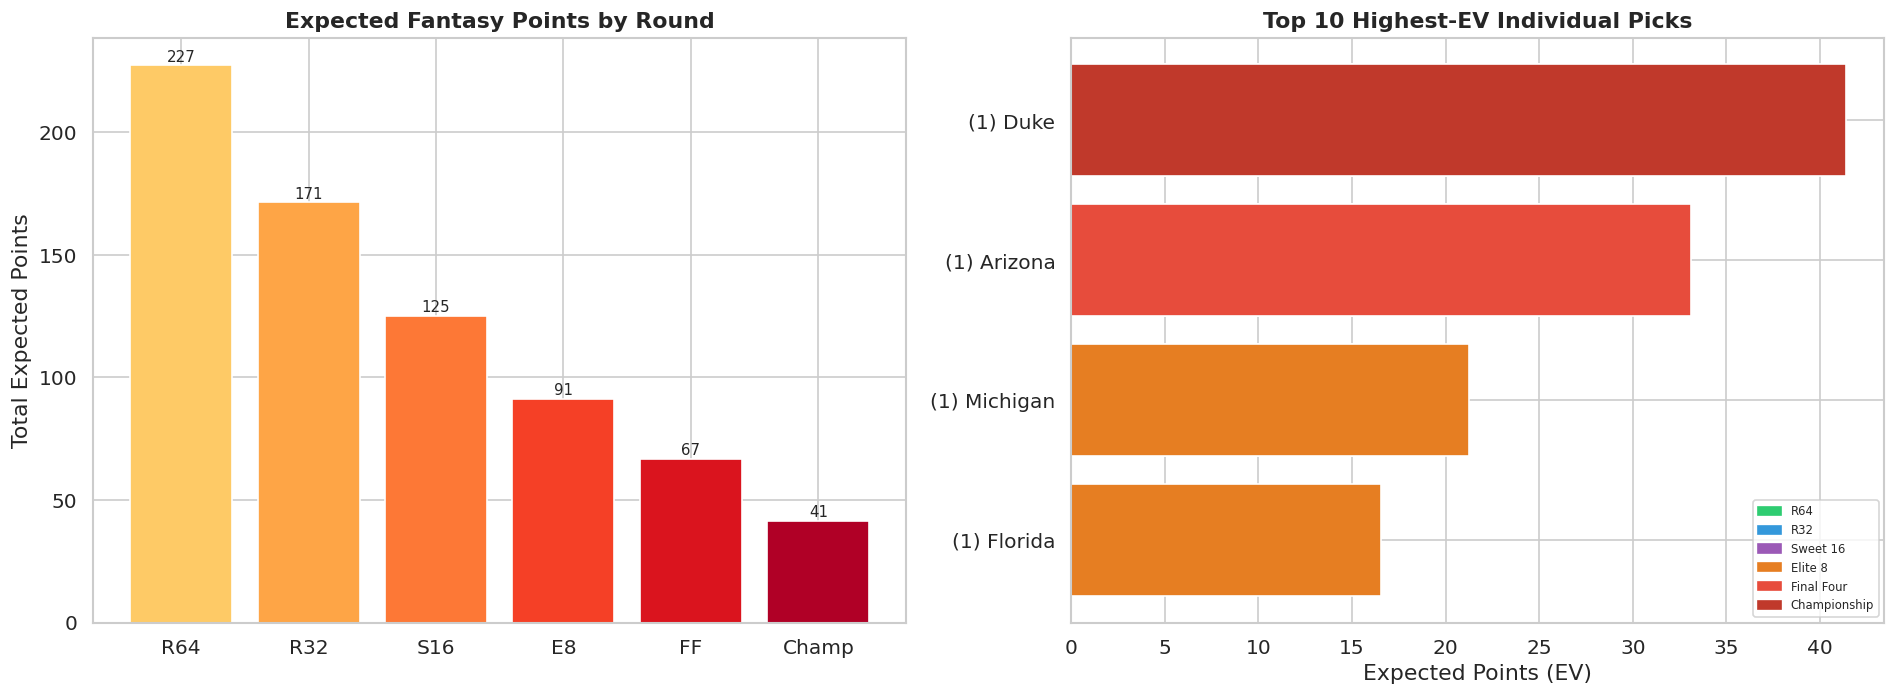

Saved: images/ev_bracket_analysis.png


In [29]:
# --- EV by Round Visualization ---
if HAS_QUANT:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Left: EV breakdown by round
    ax = axes[0]
    round_names_plot = ['R64', 'R32', 'S16', 'E8', 'FF', 'Champ']
    round_full = ['Round of 64', 'Round of 32', 'Sweet 16',
                  'Elite 8', 'Final Four', 'Championship']
    round_evs = []
    for rd in round_full:
        games = ev_results['ev_bracket'].get(rd, [])
        round_evs.append(sum(g['ev'] for g in games))

    colors = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(round_names_plot)))
    bars = ax.bar(round_names_plot, round_evs, color=colors, edgecolor='white')
    ax.set_ylabel('Total Expected Points')
    ax.set_title('Expected Fantasy Points by Round', fontweight='bold')
    for bar, val in zip(bars, round_evs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.0f}', ha='center', va='bottom', fontsize=9)

    # Right: Top 10 highest-EV individual picks
    ax = axes[1]
    all_picks = []
    for rd, games in ev_results['ev_bracket'].items():
        for g in games:
            all_picks.append({
                'team': f"({g['winner_seed']}) {g['winner']}",
                'ev': g['ev'],
                'round': rd,
            })
    top_picks = sorted(all_picks, key=lambda x: -x['ev'])[:10]
    top_picks.reverse()  # for horizontal bar chart

    y_labels = [p['team'] for p in top_picks]
    x_vals = [p['ev'] for p in top_picks]
    round_colors = {
        'Round of 64': '#2ecc71', 'Round of 32': '#3498db',
        'Sweet 16': '#9b59b6', 'Elite 8': '#e67e22',
        'Final Four': '#e74c3c', 'Championship': '#c0392b',
    }
    bar_colors = [round_colors.get(p['round'], '#888') for p in top_picks]
    ax.barh(y_labels, x_vals, color=bar_colors, edgecolor='white')
    ax.set_xlabel('Expected Points (EV)')
    ax.set_title('Top 10 Highest-EV Individual Picks', fontweight='bold')

    # Legend for rounds
    from matplotlib.patches import Patch
    legend_handles = [Patch(color=c, label=r.replace('Round of ', 'R'))
                      for r, c in round_colors.items()]
    ax.legend(handles=legend_handles, fontsize=7, loc='lower right')

    plt.tight_layout()
    plt.savefig('images/ev_bracket_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: images/ev_bracket_analysis.png")

In [30]:
# --- Sensitivity Analysis: Leverage Weight ---
if HAS_QUANT:
    print("Sensitivity analysis: varying LEVERAGE_WEIGHT from 0.0 to 2.0")
    print("=" * 70)

    sensitivity_rows = []
    for lw in [0.0, 0.5, 1.0, 1.5, 2.0]:
        test_sim = EVOptimizedSimulator(
            bracket=bracket, df=df,
            garch=garch, hmm=hmm, kalman=kalman,
            n_sims=10000, leverage_weight=lw,
        )
        test_results = test_sim.run()

        # Count upsets in leverage bracket
        n_upsets = sum(
            1 for games in test_results['leverage_bracket'].values()
            for g in games if g.get('upset', False)
        )

        # Get champion
        champ = test_results['champion']
        champ_seed = df[df['StdName'] == champ]['Seed'].values
        champ_seed = int(champ_seed[0]) if len(champ_seed) > 0 else '?'

        # Count diffs from pure EV
        n_diffs = 0
        for rd in EVOptimizedSimulator.ROUND_ORDER:
            ev_games = {(g['region'], g['loser']): g['winner']
                        for g in test_results['ev_bracket'].get(rd, [])}
            for g in test_results['leverage_bracket'].get(rd, []):
                ev_winner = ev_games.get((g['region'], g['loser']))
                if ev_winner and ev_winner != g['winner']:
                    n_diffs += 1

        sensitivity_rows.append({
            'Leverage': lw,
            'Total_EV': test_results['total_ev'],
            'Leverage_EV': test_results['total_leverage_ev'],
            'Champion': f"({champ_seed}) {champ}",
            'Upsets': n_upsets,
            'Contrarian_Flips': n_diffs,
        })

    sens_df = pd.DataFrame(sensitivity_rows)
    print(sens_df.to_string(index=False))
    print()
    print("Interpretation:")
    print("  w=0.0: Pure EV (no contrarian adjustment)")
    print("  w=1.0: Balanced leverage (default)")
    print("  w=2.0: Aggressive contrarian (maximizes differentiation)")

Sensitivity analysis: varying LEVERAGE_WEIGHT from 0.0 to 2.0
 Leverage  Total_EV  Leverage_EV Champion  Upsets  Contrarian_Flips
      0.0   722.778   722.778000 (1) Duke       3                 0
      0.5   722.778   774.025303 (1) Duke       3                 0
      1.0   722.778   826.195140 (1) Duke       6                 0
      1.5   722.778   879.236286 (1) Duke       7                 0
      2.0   722.778   932.766392 (1) Duke       8                 0

Interpretation:
  w=0.0: Pure EV (no contrarian adjustment)
  w=1.0: Balanced leverage (default)
  w=2.0: Aggressive contrarian (maximizes differentiation)


### Addendum: EV-Optimized Bracket Methodology

The unconstrained EV bracket above removes the seed-sum >= 15 constraint and instead optimizes each of the 63 game slots independently for **expected ESPN fantasy points**.

**Key differences from the constrained bracket (Section 7-9):**

1. **No historical prior blending** — the constrained model blends KenPom-derived win probabilities with historical seed upset rates (e.g., 12-over-5 happens ~36% of the time historically). The EV model uses pure model probabilities, trusting the current-season efficiency data over base rates.

2. **Per-slot optimization** — rather than choosing 4 Final Four teams and working backwards, the EV model scores every game independently: `EV = P(correct) × round_points`. This means a 70% R64 favorite is worth 7.0 EV, while a 40% Championship pick is worth 128.0 EV.

3. **Contrarian leverage** — in large ESPN bracket pools, picking the same chalk as everyone else yields no edge even if correct. The leverage layer adjusts: `leverage_EV = EV × (1 + w × (1 - public_ownership%))`. A high-EV pick that only 35% of the public makes is more valuable than an equally-high-EV pick that 90% of brackets contain.

**When to use which bracket:**
- **Constrained (Section 7-9):** Best for contests with seed-sum rules or small pools where maximizing correctness matters
- **Unconstrained EV (Section 10):** Best for large ESPN-style pools where differentiation drives expected payout